# Notebook 02bis — Analyse Exploratoire Complète du Dataset Enrichi

**Projet :** Système de Prévision et d'Optimisation des Stocks (Mémoire Master GE)  
**Auteur :** AdaMakchi  
**Date :** Mai 2026  
**Phase :** 2bis — Pré-Modélisation (pont entre Phase 2 et Phase 3)

---

## Contexte

La **Phase 2** a produit le dataset enrichi `data/processed/dataset_ml_enrichi.parquet` (349 390 lignes × 35 colonnes) en intégrant 11 variables exogènes (jours fériés, météo, IPI INSEE, vacances scolaires, périodes peak/COVID).

Avant de basculer en **Phase 3 — Modélisation IA**, ce notebook réalise une **analyse exploratoire approfondie (EDA)** du dataset enrichi pour :

1. **Auditer la qualité** des données (valeurs manquantes, doublons, types, cohérence)
2. **Étudier la distribution** de la cible `qte_demandee` et de chaque feature
3. **Caractériser la structure temporelle** (drift, stationnarité, autocorrélation)
4. **Mesurer les relations** bivariées et la multicolinéarité entre features
5. **Détecter les outliers** et les segments comportementaux
6. **Préparer les inputs** de la Phase 3 (split temporel, transformations, features finales)

---

## Plan du notebook

| Section | Contenu |
|---|---|
| 1 | Chargement & aperçu général du dataset |
| 2 | Audit qualité (NaN, doublons, types, cohérence dates) |
| 3 | Statistiques descriptives globales |
| 4 | Analyse univariée — variable cible `qte_demandee` |
| 5 | Analyse univariée — features numériques |
| 6 | Analyse univariée — features catégorielles/binaires |
| 7 | Analyse temporelle (séries journalières, mensuelles, autocorrélation) |
| 8 | Analyse bivariée — relations features ↔ cible |
| 9 | Matrice de corrélation complète & VIF (multicolinéarité) |
| 10 | Détection des outliers (IQR, Z-score) |
| 11 | Analyse par segments (pays, devise, famille article/client) |
| 12 | Préparation Phase 3 — split temporel & sélection finale |
| 13 | Synthèse & recommandations pour la modélisation |

## 1. Chargement & Aperçu Général

Chargement du dataset enrichi produit en Phase 2 et premier coup d'œil sur sa structure, ses colonnes et un échantillon de lignes.

In [1]:
# --- Imports ---
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, normaltest, spearmanr, mannwhitneyu, kruskal
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- Configuration affichage ---
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# --- Chemins projet ---
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH    = PROJECT_ROOT / "data" / "processed" / "dataset_ml_enrichi.parquet"
REPORTS_DIR  = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print(f"Projet      : {PROJECT_ROOT}")
print(f"Dataset     : {DATA_PATH}")
print(f"Reports dir : {REPORTS_DIR}")

Projet      : C:\Users\lenovo\Desktop\Extraction livraison client 2021-2025
Dataset     : C:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\data\processed\dataset_ml_enrichi.parquet
Reports dir : C:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\reports


In [2]:
# --- Chargement du dataset enrichi ---
df = pd.read_parquet(DATA_PATH)

print(f"Dimensions   : {df.shape[0]:,} lignes  x  {df.shape[1]} colonnes")
print(f"Mémoire      : {df.memory_usage(deep=True).sum() / 1e6:,.1f} Mo")
print(f"Période      : {df['date_cmd'].min().date()}  ->  {df['date_cmd'].max().date()}")
print()
print("Aperçu (5 premières lignes) :")
df.head()

Dimensions   : 349,390 lignes  x  35 colonnes
Mémoire      : 86.6 Mo
Période      : 2020-09-23  ->  2025-12-23

Aperçu (5 premières lignes) :


,qte_demandee,prix,annee_cmd,mois_cmd,trimestre_cmd,semaine_cmd,jour_semaine_cmd,est_fin_mois_cmd,annee_liv_dem,mois_liv_dem,trimestre_liv_dem,jour_semaine_liv_dem,est_weekend_liv_dem,delai_demande_jours,statut_enc,devise_enc,pays_enc,famille_activite_client_enc,famille_activite_article_enc,segment_enc,type_activite_enc,code_client_freq,code_article_freq,en_retard,date_cmd,date_liv_dem,est_jour_ferie_cmd,est_jour_ferie_liv_dem,pluie_mm_liv_dem,vent_max_kmh_liv_dem,temp_min_liv_dem,ipi_valeur,est_vacances_scolaires_liv_dem,est_periode_peak_liv_dem,est_periode_covid
0,300,89.0000,2020,9,3,39,2,0,2021,1,1,4,0,114,1,1,37,2,1,4,7,296,115,1.0000,2020-09-23,2021-01-15,0,0,96.2000,43.7000,-3.1000,109.8300,0,0,0
1,12,6.7700,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,4,159,6253,0.0000,2020-10-08,2021-01-04,0,0,96.2000,43.7000,-3.1000,112.8600,0,0,0
2,1,0.0000,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,3,10,159,24,0.0000,2020-10-08,2021-01-04,0,0,96.2000,43.7000,-3.1000,112.8600,0,0,0
3,1,19.2200,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,782,0.0000,2020-10-08,2021-01-04,0,0,96.2000,43.7000,-3.1000,112.8600,0,0,0
4,3,16.3300,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,1632,0.0000,2020-10-08,2021-01-04,0,0,96.2000,43.7000,-3.1000,112.8600,0,0,0


In [3]:
# --- Catégorisation des colonnes par rôle ---
TARGET = "qte_demandee"

cols_temporelles = [
    "date_cmd", "date_liv_dem",
    "annee_cmd", "mois_cmd", "trimestre_cmd", "semaine_cmd",
    "jour_semaine_cmd", "est_fin_mois_cmd",
    "annee_liv_dem", "mois_liv_dem", "trimestre_liv_dem",
    "jour_semaine_liv_dem", "est_weekend_liv_dem",
    "delai_demande_jours",
]

cols_categorielles = [
    "statut_enc", "devise_enc", "pays_enc",
    "famille_activite_client_enc", "famille_activite_article_enc",
    "segment_enc", "type_activite_enc",
    "code_client_freq", "code_article_freq",
]

cols_exogenes = [
    "est_jour_ferie_cmd", "est_jour_ferie_liv_dem",
    "pluie_mm_liv_dem", "vent_max_kmh_liv_dem", "temp_min_liv_dem",
    "ipi_valeur",
    "est_vacances_scolaires_liv_dem", "est_periode_peak_liv_dem", "est_periode_covid",
]

cols_business = ["prix", "en_retard"]

print("Découpage des 35 colonnes :")
print(f"  - Cible           : 1  ({TARGET})")
print(f"  - Temporelles     : {len(cols_temporelles)}")
print(f"  - Catégorielles   : {len(cols_categorielles)}")
print(f"  - Exogènes (P2)   : {len(cols_exogenes)}")
print(f"  - Business        : {len(cols_business)}")
print(f"  - Total            : {1 + len(cols_temporelles) + len(cols_categorielles) + len(cols_exogenes) + len(cols_business)}")

Découpage des 35 colonnes :
  - Cible           : 1  (qte_demandee)
  - Temporelles     : 14
  - Catégorielles   : 9
  - Exogènes (P2)   : 9
  - Business        : 2
  - Total            : 35


## 2. Audit Qualité du Dataset

Vérifications systématiques :

- **Valeurs manquantes** par colonne
- **Doublons** exacts et fonctionnels (même client, même article, même date)
- **Types** de données (cohérence avec la sémantique métier)
- **Cohérence des dates** : `date_liv_dem >= date_cmd`
- **Plages de valeurs** aberrantes (négatifs interdits, dates futures suspectes)

In [4]:
# --- 2.1 Valeurs manquantes ---
nan_stats = pd.DataFrame({
    "nb_nan":   df.isna().sum(),
    "pct_nan":  100 * df.isna().mean(),
    "dtype":    df.dtypes.astype(str),
})
nan_stats = nan_stats[nan_stats["nb_nan"] > 0].sort_values("nb_nan", ascending=False)

if len(nan_stats):
    print(f"Colonnes avec valeurs manquantes : {len(nan_stats)}")
    display(nan_stats)
else:
    print("Aucune valeur manquante détectée.")

Colonnes avec valeurs manquantes : 1


,nb_nan,pct_nan,dtype
en_retard,332,0.0950,float64


In [5]:
# --- 2.2 Doublons ---
nb_doublons_exact = df.duplicated().sum()

# Doublons "fonctionnels" : même client + même article + même date + même quantité
key_cols = ["code_client_freq", "code_article_freq", "date_cmd", "qte_demandee"]
nb_doublons_fonc = df.duplicated(subset=key_cols).sum()

print(f"Doublons exacts (toutes colonnes)            : {nb_doublons_exact:,}  ({100*nb_doublons_exact/len(df):.3f} %)")
print(f"Doublons fonctionnels (client+article+date+q): {nb_doublons_fonc:,}  ({100*nb_doublons_fonc/len(df):.3f} %)")

if nb_doublons_exact > 0:
    print("\nÉchantillon de doublons exacts :")
    display(df[df.duplicated(keep=False)].sort_values(key_cols).head(6))

Doublons exacts (toutes colonnes)            : 2,237  (0.640 %)
Doublons fonctionnels (client+article+date+q): 3,544  (1.014 %)

Échantillon de doublons exacts :


,qte_demandee,prix,annee_cmd,mois_cmd,trimestre_cmd,semaine_cmd,jour_semaine_cmd,est_fin_mois_cmd,annee_liv_dem,mois_liv_dem,trimestre_liv_dem,jour_semaine_liv_dem,est_weekend_liv_dem,delai_demande_jours,statut_enc,devise_enc,pays_enc,famille_activite_client_enc,famille_activite_article_enc,segment_enc,type_activite_enc,code_client_freq,code_article_freq,en_retard,date_cmd,date_liv_dem,est_jour_ferie_cmd,est_jour_ferie_liv_dem,pluie_mm_liv_dem,vent_max_kmh_liv_dem,temp_min_liv_dem,ipi_valeur,est_vacances_scolaires_liv_dem,est_periode_peak_liv_dem,est_periode_covid
111949,6,62.3700,2022,6,2,26,1,1,2022,7,3,1,0,7,1,1,27,1,0,3,11,1,287,1.0000,2022-06-28,2022-07-05,0,0,24.8000,27.3000,10.4000,103.7100,0,0,0
111954,6,62.3700,2022,6,2,26,1,1,2022,7,3,1,0,7,1,1,27,1,0,3,11,1,287,0.0000,2022-06-28,2022-07-05,0,0,24.8000,27.3000,10.4000,103.7100,0,0,0
111958,6,62.3700,2022,6,2,26,1,1,2022,7,3,1,0,7,1,1,27,1,0,3,11,1,287,1.0000,2022-06-28,2022-07-05,0,0,24.8000,27.3000,10.4000,103.7100,0,0,0
111971,6,62.3700,2022,6,2,26,1,1,2022,7,3,0,0,6,1,1,27,1,0,3,11,1,287,0.0000,2022-06-28,2022-07-04,0,0,24.8000,27.3000,10.4000,103.7100,0,0,0
111972,6,62.3700,2022,6,2,26,1,1,2022,7,3,1,0,7,1,1,27,1,0,3,11,1,287,1.0000,2022-06-28,2022-07-05,0,0,24.8000,27.3000,10.4000,103.7100,0,0,0
111975,6,62.3700,2022,6,2,26,1,1,2022,7,3,1,0,7,1,1,27,1,0,3,11,1,287,1.0000,2022-06-28,2022-07-05,0,0,24.8000,27.3000,10.4000,103.7100,0,0,0


In [6]:
# --- 2.3 Cohérence des dates ---
incoherences = df["date_liv_dem"] < df["date_cmd"]
print(f"Lignes avec date_liv_dem < date_cmd : {incoherences.sum():,}  ({100*incoherences.mean():.3f} %)")

# Délai de livraison demandé
delai = (df["date_liv_dem"] - df["date_cmd"]).dt.days
print(f"\nDélai demandé (jours) — statistiques :")
print(f"  min      : {delai.min()}")
print(f"  médiane  : {delai.median()}")
print(f"  moyenne  : {delai.mean():.1f}")
print(f"  max      : {delai.max()}")
print(f"  > 365 j  : {(delai > 365).sum():,} lignes")
print(f"  négatifs : {(delai < 0).sum():,} lignes")

# Plages temporelles
print(f"\nPlage de dates :")
print(f"  date_cmd     : {df['date_cmd'].min().date()} -> {df['date_cmd'].max().date()}")
print(f"  date_liv_dem : {df['date_liv_dem'].min().date()} -> {df['date_liv_dem'].max().date()}")

Lignes avec date_liv_dem < date_cmd : 96  (0.027 %)

Délai demandé (jours) — statistiques :
  min      : -61
  médiane  : 5.0
  moyenne  : 6.2
  max      : 388
  > 365 j  : 3 lignes
  négatifs : 96 lignes

Plage de dates :
  date_cmd     : 2020-09-23 -> 2025-12-23
  date_liv_dem : 2021-01-04 -> 2025-12-23


In [7]:
# --- 2.4 Plages de valeurs aberrantes ---
controles = {
    "qte_demandee <= 0":  (df["qte_demandee"] <= 0).sum(),
    "prix < 0":           (df["prix"] < 0).sum(),
    "prix == 0":          (df["prix"] == 0).sum(),
    "delai_demande < 0":  (df["delai_demande_jours"] < 0).sum(),
    "annee_cmd < 2020":   (df["annee_cmd"] < 2020).sum(),
    "annee_cmd > 2026":   (df["annee_cmd"] > 2026).sum(),
    "ipi_valeur NaN":     df["ipi_valeur"].isna().sum(),
    "pluie_mm NaN":       df["pluie_mm_liv_dem"].isna().sum(),
}
ctrl_df = pd.DataFrame(controles.items(), columns=["Contrôle", "Nb lignes"])
ctrl_df["Pct %"] = (100 * ctrl_df["Nb lignes"] / len(df)).round(3)
display(ctrl_df)

,Contrôle,Nb lignes,Pct %
0,qte_demandee <= 0,0,0.0000
1,prix < 0,0,0.0000
2,prix == 0,7453,2.1330
3,delai_demande < 0,96,0.0270
4,annee_cmd < 2020,0,0.0000
5,annee_cmd > 2026,0,0.0000
6,ipi_valeur NaN,0,0.0000
7,pluie_mm NaN,0,0.0000


## 3. Statistiques Descriptives Globales

Vue d'ensemble des distributions de toutes les variables numériques (count, mean, std, min, quartiles, max). C'est la base qui sert à détecter les variables fortement asymétriques, à variance nulle (constantes), ou à plage incohérente.

In [8]:
# --- 3.1 Statistiques descriptives complètes ---
desc = df.describe(include=[np.number]).T
desc["skew"] = df.select_dtypes(include=np.number).skew()
desc["kurtosis"] = df.select_dtypes(include=np.number).kurtosis()
desc["n_unique"] = df.select_dtypes(include=np.number).nunique()
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis", "n_unique"]]
display(desc.round(3))

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,n_unique
qte_demandee,"349,390.0000",22.7900,226.6550,1.0000,2.0000,4.0000,12.0000,"34,020.0000",82.6030,"10,441.0920",366
prix,"349,390.0000",40.4110,64.8320,0.0000,8.3500,18.4700,49.4800,"5,220.0000",10.0300,498.4570,8311
annee_cmd,"349,390.0000","2,022.9450",1.4330,"2,020.0000","2,022.0000","2,023.0000","2,024.0000","2,025.0000",0.0040,-1.2860,6
mois_cmd,"349,390.0000",6.1250,3.5530,1.0000,3.0000,6.0000,9.0000,12.0000,0.1230,-1.3040,12
trimestre_cmd,"349,390.0000",2.3840,1.1550,1.0000,1.0000,2.0000,3.0000,4.0000,0.1580,-1.4200,4
semaine_cmd,"349,390.0000",24.8660,15.4530,1.0000,11.0000,24.0000,39.0000,53.0000,0.1220,-1.3080,53
jour_semaine_cmd,"349,390.0000",1.7020,1.3610,0.0000,0.0000,2.0000,3.0000,6.0000,0.2450,-1.1140,7
est_fin_mois_cmd,"349,390.0000",0.1960,0.3970,0.0000,0.0000,0.0000,0.0000,1.0000,1.5280,0.3340,2
annee_liv_dem,"349,390.0000","2,022.9710",1.4250,"2,021.0000","2,022.0000","2,023.0000","2,024.0000","2,025.0000",0.0060,-1.3160,5
mois_liv_dem,"349,390.0000",6.0260,3.5020,1.0000,3.0000,6.0000,9.0000,12.0000,0.1510,-1.2780,12


In [9]:
# --- 3.2 Détection des colonnes problématiques pour le ML ---
problemes = []

for col in df.select_dtypes(include=np.number).columns:
    n_unique = df[col].nunique()
    if n_unique == 1:
        problemes.append((col, "CONSTANTE", f"{n_unique} valeur unique"))
    elif df[col].std() < 1e-6:
        problemes.append((col, "QUASI-CONSTANTE", f"std = {df[col].std():.2e}"))
    elif abs(df[col].skew()) > 10:
        problemes.append((col, "ASYMÉTRIE EXTRÊME", f"skew = {df[col].skew():.1f}"))

if problemes:
    print("Colonnes à surveiller :")
    display(pd.DataFrame(problemes, columns=["Colonne", "Problème", "Détail"]))
else:
    print("Aucune colonne constante ou à asymétrie extrême.")

Colonnes à surveiller :


,Colonne,Problème,Détail
0,qte_demandee,ASYMÉTRIE EXTRÊME,skew = 82.6
1,prix,ASYMÉTRIE EXTRÊME,skew = 10.0
2,est_weekend_liv_dem,ASYMÉTRIE EXTRÊME,skew = 26.3
3,statut_enc,ASYMÉTRIE EXTRÊME,skew = -32.4
4,devise_enc,ASYMÉTRIE EXTRÊME,skew = 17.9
5,est_jour_ferie_cmd,ASYMÉTRIE EXTRÊME,skew = 80.4
6,est_jour_ferie_liv_dem,ASYMÉTRIE EXTRÊME,skew = 55.6


## 4. Analyse Univariée — Variable Cible `qte_demandee`

C'est **la variable que le modèle de Phase 3 devra prédire**. Sa forme conditionne :

- le choix de la fonction objectif (RMSE vs MAE vs quantile loss)
- la nécessité d'une transformation (log, Box-Cox, Yeo-Johnson)
- le choix d'un éventuel modèle d'inflation (zero-inflated, Tweedie)

On étudie : distribution brute, distribution log, tests de normalité, queue droite (top 1 %).

In [10]:
# --- 4.1 Statistiques détaillées de la cible ---
y = df[TARGET]

stats_target = {
    "n":             len(y),
    "moyenne":       y.mean(),
    "médiane":       y.median(),
    "écart-type":    y.std(),
    "min":           y.min(),
    "max":           y.max(),
    "skewness":      skew(y),
    "kurtosis":      kurtosis(y),
    "p90":           y.quantile(0.90),
    "p95":           y.quantile(0.95),
    "p99":           y.quantile(0.99),
    "p99.9":         y.quantile(0.999),
    "% qte == 1":    100 * (y == 1).mean(),
    "% qte <= 10":   100 * (y <= 10).mean(),
    "% qte > 100":   100 * (y > 100).mean(),
}
pd.Series(stats_target, name="qte_demandee").to_frame().round(3)

,qte_demandee
n,"349,390.0000"
moyenne,22.7900
médiane,4.0000
écart-type,226.6550
min,1.0000
max,"34,020.0000"
skewness,82.6030
kurtosis,"10,440.9430"
p90,30.0000
p95,60.0000


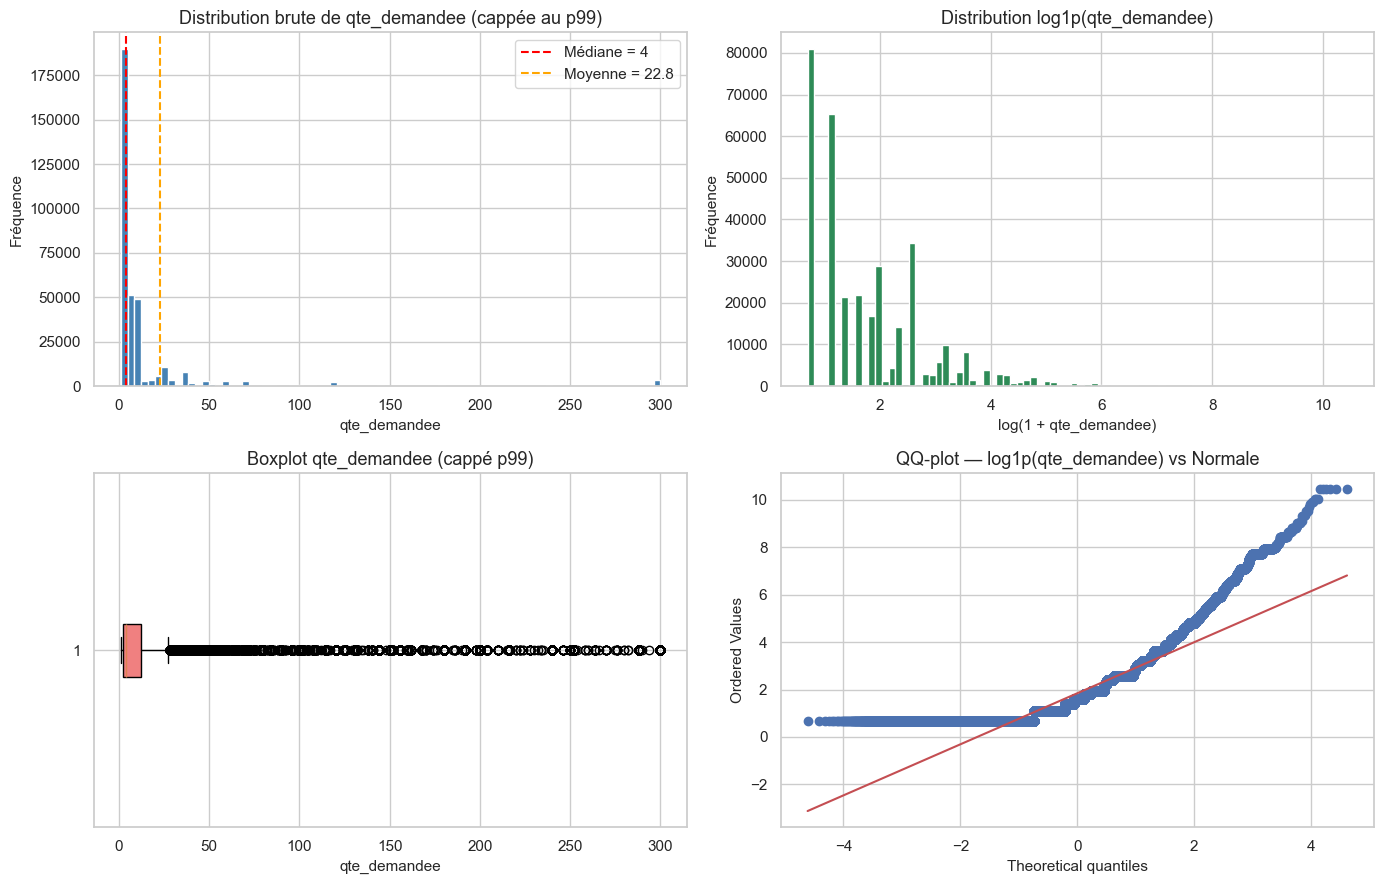

Figure : C:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\reports\eda_target_distribution.png


In [11]:
# --- 4.2 Distribution brute vs log de la cible ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Histogramme brut (cappé pour visualisation)
y_cap = y.clip(upper=y.quantile(0.99))
axes[0, 0].hist(y_cap, bins=80, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribution brute de qte_demandee (cappée au p99)")
axes[0, 0].set_xlabel("qte_demandee"); axes[0, 0].set_ylabel("Fréquence")
axes[0, 0].axvline(y.median(), color="red", ls="--", label=f"Médiane = {y.median():.0f}")
axes[0, 0].axvline(y.mean(), color="orange", ls="--", label=f"Moyenne = {y.mean():.1f}")
axes[0, 0].legend()

# Distribution en échelle log
axes[0, 1].hist(np.log1p(y), bins=80, color="seagreen", edgecolor="white")
axes[0, 1].set_title("Distribution log1p(qte_demandee)")
axes[0, 1].set_xlabel("log(1 + qte_demandee)"); axes[0, 1].set_ylabel("Fréquence")

# Boxplot
axes[1, 0].boxplot(y_cap, vert=False, patch_artist=True,
                   boxprops=dict(facecolor="lightcoral"))
axes[1, 0].set_title("Boxplot qte_demandee (cappé p99)")
axes[1, 0].set_xlabel("qte_demandee")

# QQ-plot log
stats.probplot(np.log1p(y), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ-plot — log1p(qte_demandee) vs Normale")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Figure : {REPORTS_DIR / 'eda_target_distribution.png'}")

In [12]:
# --- 4.3 Tests de normalité sur log(qte) ---
# D'Agostino-Pearson sur l'échantillon log1p
sample_log = np.log1p(y.sample(5000, random_state=42))
k2, p_dagostino = normaltest(sample_log)

# Skewness/kurtosis avant et après log
print("=== Tests de normalité sur log1p(qte_demandee) ===")
print(f"D'Agostino-Pearson :  K² = {k2:.2f}   p-value = {p_dagostino:.2e}")
print(f"  -> {'NON normal' if p_dagostino < 0.05 else 'normal'} (au seuil 5 %)")
print()
print("Comparaison brute vs log1p :")
print(f"  skew brut    : {skew(y):+.2f}  | skew log1p    : {skew(np.log1p(y)):+.2f}")
print(f"  kurt brut    : {kurtosis(y):+.2f}  | kurt log1p    : {kurtosis(np.log1p(y)):+.2f}")
print()
print("Conclusion : la cible est fortement asymétrique à droite (queue lourde).")
print("Recommandation Phase 3 : entraîner sur log1p(qte_demandee) puis re-transformer en expm1.")

=== Tests de normalité sur log1p(qte_demandee) ===
D'Agostino-Pearson :  K² = 1270.31   p-value = 1.43e-276
  -> NON normal (au seuil 5 %)

Comparaison brute vs log1p :
  skew brut    : +82.60  | skew log1p    : +1.44
  kurt brut    : +10440.94  | kurt log1p    : +2.70

Conclusion : la cible est fortement asymétrique à droite (queue lourde).
Recommandation Phase 3 : entraîner sur log1p(qte_demandee) puis re-transformer en expm1.


## 5. Analyse Univariée — Features Numériques

Distribution de chaque feature numérique continue. Identification des features à transformer (log, standardisation) avant entraînement.

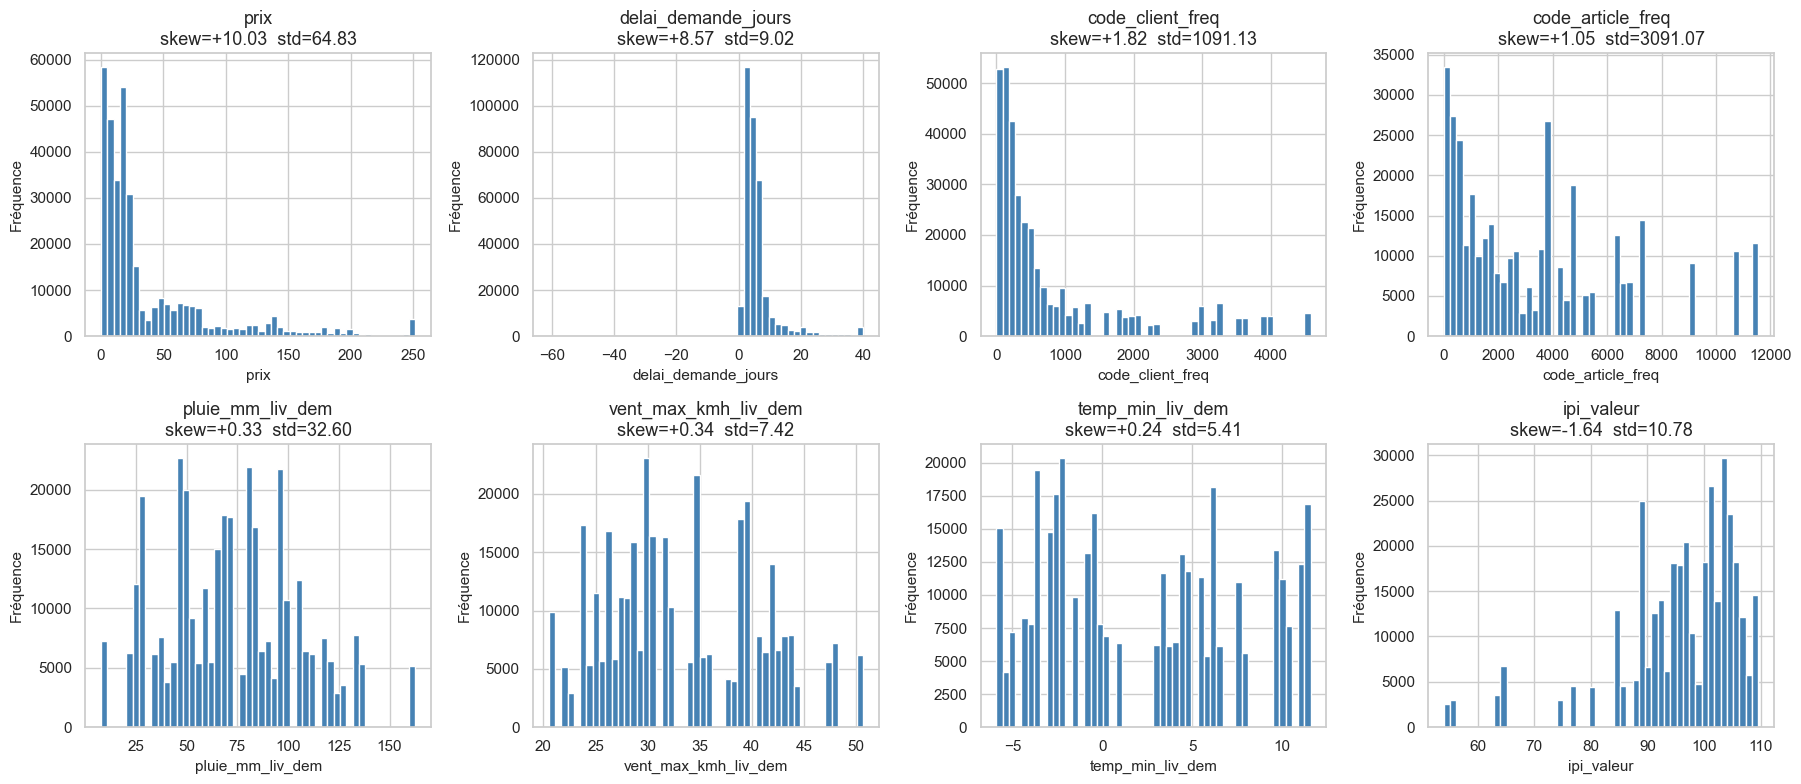

Figure : C:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\reports\eda_features_numeriques.png


In [13]:
# --- 5.1 Features numériques continues : histogrammes ---
features_num = [
    "prix", "delai_demande_jours",
    "code_client_freq", "code_article_freq",
    "pluie_mm_liv_dem", "vent_max_kmh_liv_dem", "temp_min_liv_dem",
    "ipi_valeur",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, features_num):
    serie = df[col].dropna()
    serie_cap = serie.clip(upper=serie.quantile(0.99))
    ax.hist(serie_cap, bins=50, color="steelblue", edgecolor="white")
    ax.set_title(f"{col}\nskew={skew(serie):+.2f}  std={serie.std():.2f}")
    ax.set_xlabel(col); ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_features_numeriques.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Figure : {REPORTS_DIR / 'eda_features_numeriques.png'}")

## 6. Analyse Univariée — Variables Catégorielles et Binaires

Distribution des modalités. Détection des modalités rares (< 1 % d'occurrences) qui peuvent biaiser le modèle. Visualisation des variables binaires exogènes.

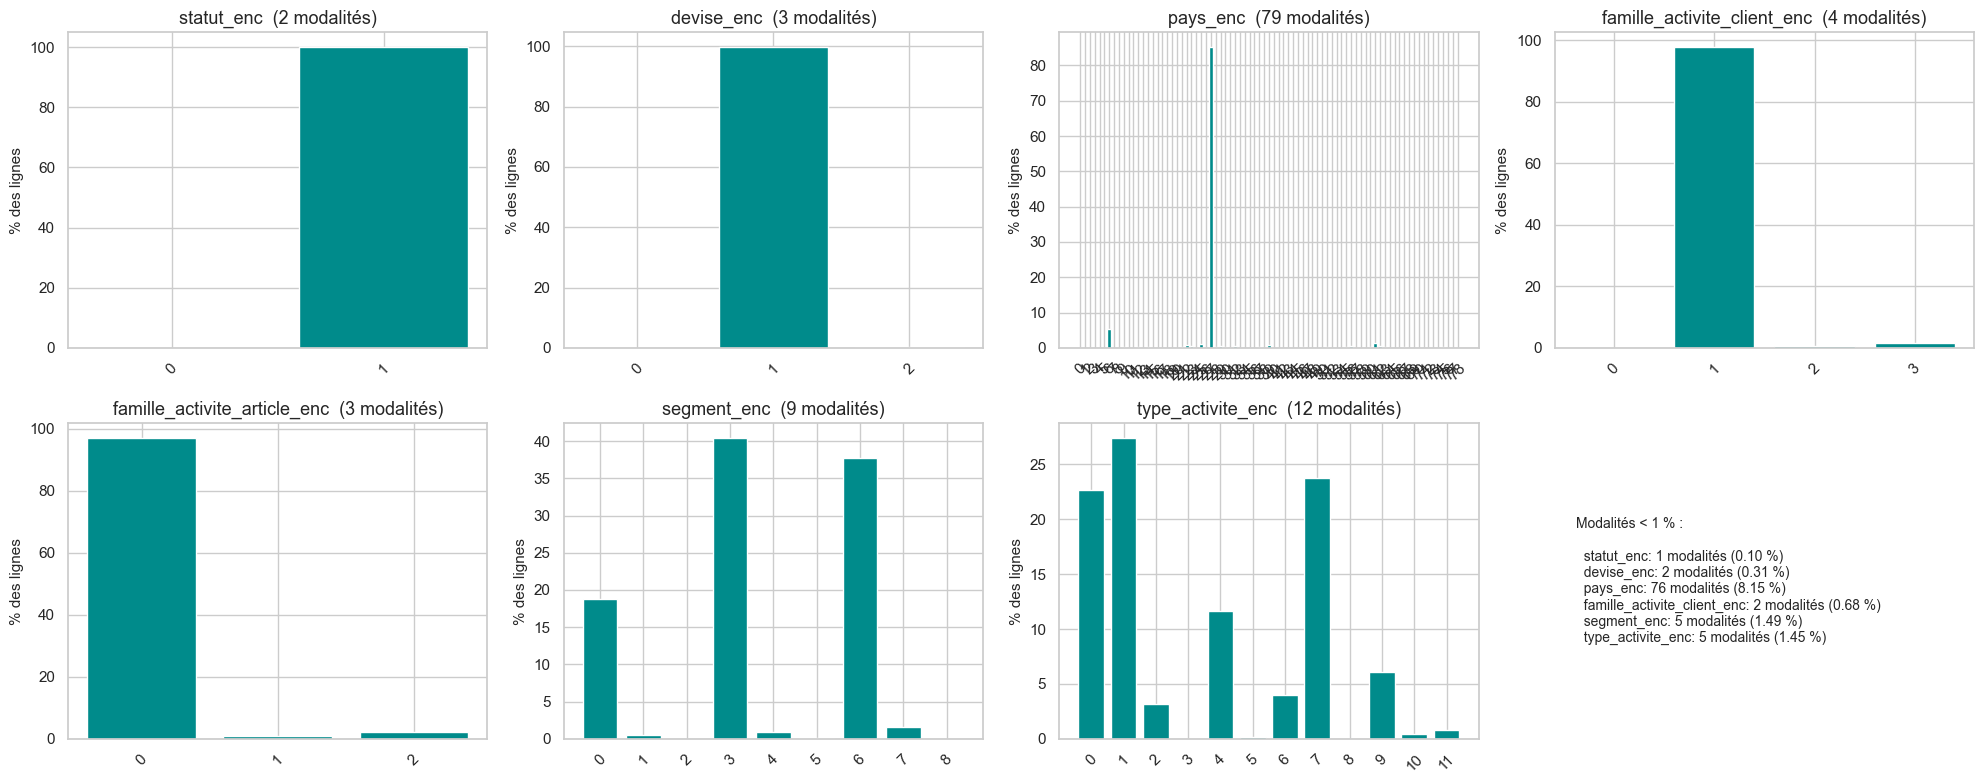

In [14]:
# --- 6.1 Variables catégorielles encodées : distribution ---
cols_cat_view = [
    "statut_enc", "devise_enc", "pays_enc",
    "famille_activite_client_enc", "famille_activite_article_enc",
    "segment_enc", "type_activite_enc",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, cols_cat_view):
    vc = df[col].value_counts(normalize=True).sort_index() * 100
    ax.bar(vc.index.astype(str), vc.values, color="darkcyan", edgecolor="white")
    ax.set_title(f"{col}  ({df[col].nunique()} modalités)")
    ax.set_ylabel("% des lignes")
    ax.tick_params(axis="x", rotation=45)

# Dernier subplot : modalités rares
axes.flat[-1].axis("off")
rares = []
for col in cols_cat_view:
    vc = df[col].value_counts(normalize=True)
    nb_rares = (vc < 0.01).sum()
    if nb_rares:
        rares.append((col, nb_rares, f"{vc[vc < 0.01].sum()*100:.2f} %"))
axes.flat[-1].text(0.05, 0.5,
                   "Modalités < 1 % :\n\n" + "\n".join(f"  {c}: {n} modalités ({p})" for c, n, p in rares),
                   transform=axes.flat[-1].transAxes, fontsize=10, va="center")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_features_categorielles.png", dpi=120, bbox_inches="tight")
plt.show()

,Variable,% lignes = 1,% lignes = 0
0,est_jour_ferie_cmd,0.0200,99.9800
1,est_jour_ferie_liv_dem,0.0300,99.9700
2,est_weekend_liv_dem,0.1400,99.8600
3,est_fin_mois_cmd,19.6500,80.3500
4,est_vacances_scolaires_liv_dem,29.4300,70.5700
5,est_periode_peak_liv_dem,21.9400,78.0600
6,est_periode_covid,18.1200,81.8800


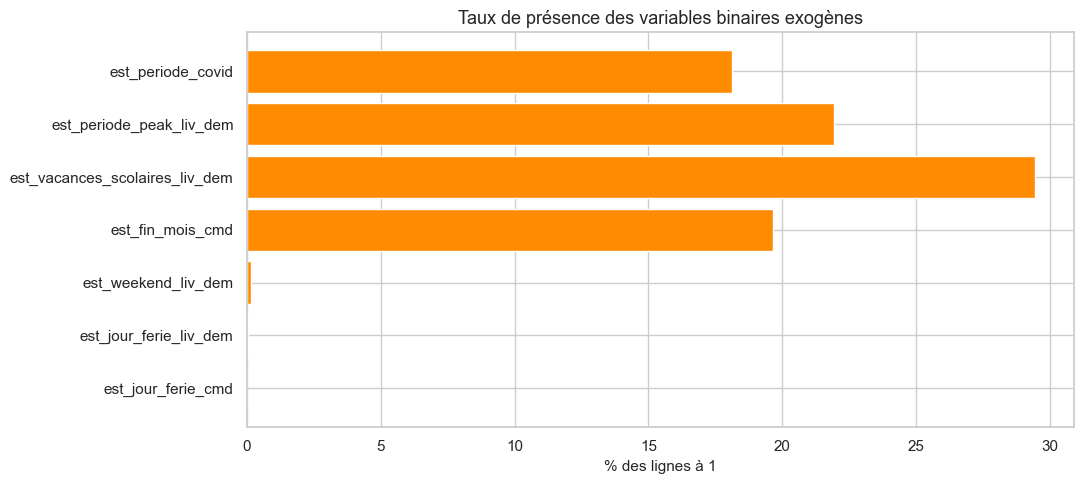

In [15]:
# --- 6.2 Variables binaires exogènes : taux de présence ---
cols_bin = [
    "est_jour_ferie_cmd", "est_jour_ferie_liv_dem",
    "est_weekend_liv_dem", "est_fin_mois_cmd",
    "est_vacances_scolaires_liv_dem", "est_periode_peak_liv_dem", "est_periode_covid",
]

bin_summary = pd.DataFrame({
    "Variable": cols_bin,
    "% lignes = 1": [100 * df[c].mean() for c in cols_bin],
    "% lignes = 0": [100 * (1 - df[c].mean()) for c in cols_bin],
}).round(2)
display(bin_summary)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(bin_summary["Variable"], bin_summary["% lignes = 1"], color="darkorange", edgecolor="white")
ax.set_xlabel("% des lignes à 1")
ax.set_title("Taux de présence des variables binaires exogènes")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_features_binaires.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Analyse Temporelle Approfondie

La Phase 2 a déjà décomposé la série mensuelle globale. Cette section ajoute :

- **Série journalière** de la demande (granularité fine)
- **Tests de stationnarité** ADF & KPSS
- **Autocorrélation** ACF/PACF pour identifier les lags pertinents en Phase 3
- **Évolution annuelle** de la demande, du prix, du délai et du taux de retard
- **Heatmap mois × année** pour visualiser le drift entre périodes

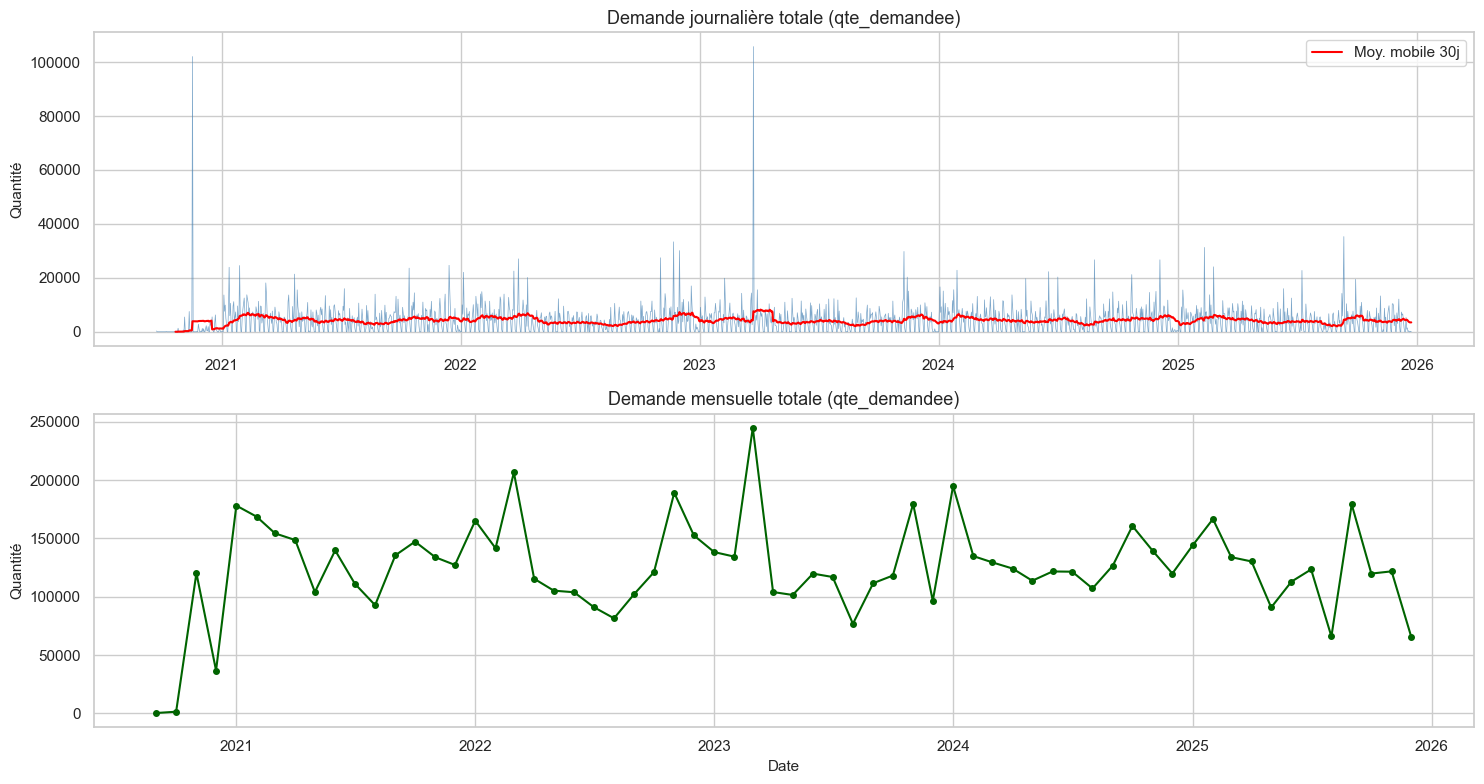

In [16]:
# --- 7.1 Série journalière et mensuelle de la demande ---
serie_jour = df.groupby("date_cmd")[TARGET].sum().asfreq("D", fill_value=0)
serie_mois = df.groupby(pd.Grouper(key="date_cmd", freq="MS"))[TARGET].sum()

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(serie_jour.index, serie_jour.values, color="steelblue", lw=0.5, alpha=0.7)
axes[0].plot(serie_jour.index, serie_jour.rolling(30).mean(), color="red", lw=1.5, label="Moy. mobile 30j")
axes[0].set_title("Demande journalière totale (qte_demandee)")
axes[0].set_ylabel("Quantité"); axes[0].legend()

axes[1].plot(serie_mois.index, serie_mois.values, color="darkgreen", lw=1.5, marker="o", ms=4)
axes[1].set_title("Demande mensuelle totale (qte_demandee)")
axes[1].set_ylabel("Quantité")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_series_temporelles.png", dpi=120, bbox_inches="tight")
plt.show()

In [17]:
# --- 7.2 Tests de stationnarité (ADF + KPSS) ---
def test_stationnarite(serie, nom):
    adf_stat, adf_p, *_ = adfuller(serie.dropna(), autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression="c", nlags="auto")
    return {
        "Série":          nom,
        "ADF stat":       round(adf_stat, 3),
        "ADF p-value":    round(adf_p, 4),
        "ADF conclu.":    "stationnaire" if adf_p < 0.05 else "NON stationnaire",
        "KPSS stat":      round(kpss_stat, 3),
        "KPSS p-value":   round(kpss_p, 4),
        "KPSS conclu.":   "stationnaire" if kpss_p > 0.05 else "NON stationnaire",
    }

resultats_stat = pd.DataFrame([
    test_stationnarite(serie_mois, "Mensuelle brute"),
    test_stationnarite(serie_mois.diff().dropna(), "Mensuelle Δ1"),
    test_stationnarite(np.log1p(serie_mois), "log1p mensuelle"),
])
display(resultats_stat)
print("\nNote : ADF (H0=non stationnaire) et KPSS (H0=stationnaire) sont complémentaires.")
print("Si ADF p<0.05 ET KPSS p>0.05 -> série stationnaire.")

C:\Users\lenovo\AppData\Local\Temp\ipykernel_21140\4043079426.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression="c", nlags="auto")
C:\Users\lenovo\AppData\Local\Temp\ipykernel_21140\4043079426.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression="c", nlags="auto")
C:\Users\lenovo\AppData\Local\Temp\ipykernel_21140\4043079426.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression="c", nlags="auto")


,Série,ADF stat,ADF p-value,ADF conclu.,KPSS stat,KPSS p-value,KPSS conclu.
0,Mensuelle brute,-4.9440,0.0000,stationnaire,0.1190,0.1000,stationnaire
1,Mensuelle Δ1,-4.4420,0.0002,stationnaire,0.1840,0.1000,stationnaire
2,log1p mensuelle,-4.5730,0.0001,stationnaire,0.3230,0.1000,stationnaire



Note : ADF (H0=non stationnaire) et KPSS (H0=stationnaire) sont complémentaires.
Si ADF p<0.05 ET KPSS p>0.05 -> série stationnaire.


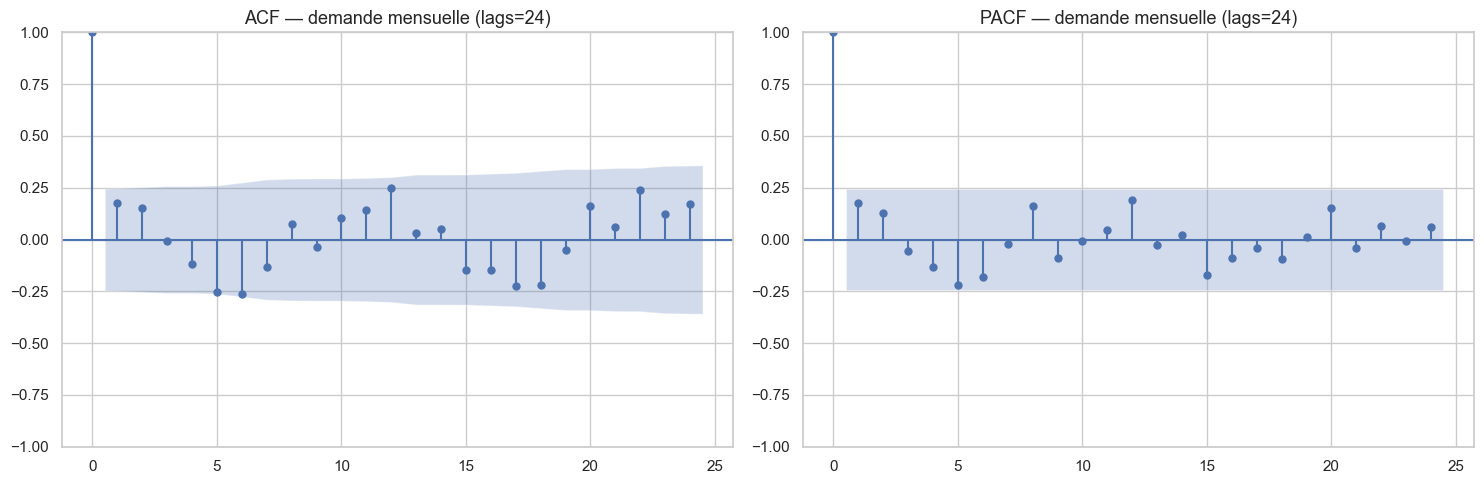


Lags ACF significatifs (|r| > 0.245) : [5, 6, 12]
Interprétation : ces lags sont des candidats forts pour les features de lag en Phase 3.


In [18]:
# --- 7.3 Autocorrélation ACF / PACF ---
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(serie_mois.dropna(),  lags=24, ax=axes[0], title="ACF — demande mensuelle (lags=24)")
plot_pacf(serie_mois.dropna(), lags=24, ax=axes[1], title="PACF — demande mensuelle (lags=24)", method="ywm")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_acf_pacf.png", dpi=120, bbox_inches="tight")
plt.show()

# Pics significatifs
acf_vals = acf(serie_mois.dropna(), nlags=24)
seuil = 1.96 / np.sqrt(len(serie_mois))
pics = [i for i, v in enumerate(acf_vals) if i > 0 and abs(v) > seuil]
print(f"\nLags ACF significatifs (|r| > {seuil:.3f}) : {pics}")
print("Interprétation : ces lags sont des candidats forts pour les features de lag en Phase 3.")

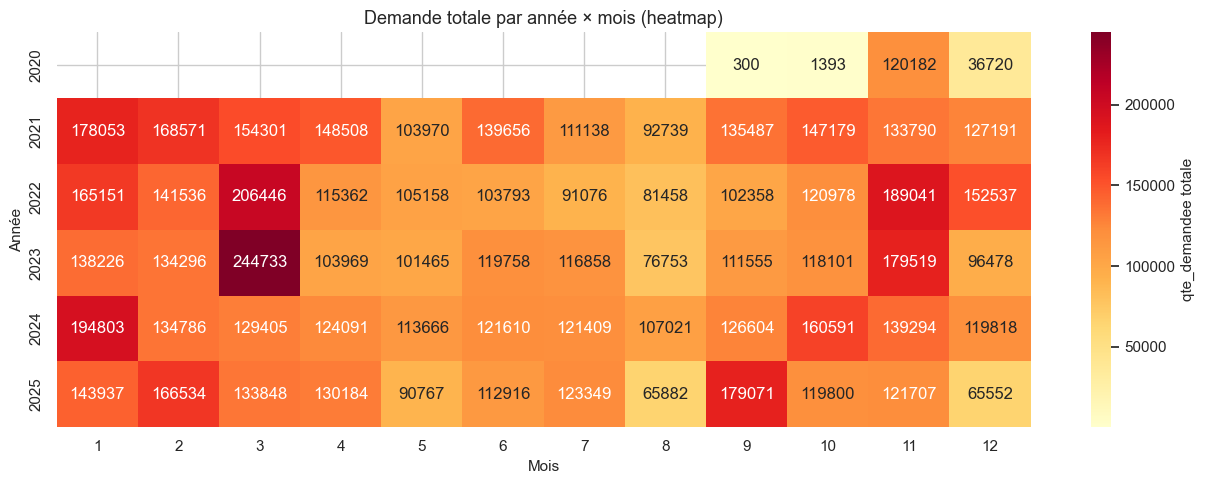

In [19]:
# --- 7.4 Heatmap année × mois de la demande ---
pivot_an_mois = df.pivot_table(
    index="annee_cmd", columns="mois_cmd",
    values=TARGET, aggfunc="sum"
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot_an_mois, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "qte_demandee totale"})
ax.set_title("Demande totale par année × mois (heatmap)")
ax.set_xlabel("Mois"); ax.set_ylabel("Année")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_heatmap_annee_mois.png", dpi=120, bbox_inches="tight")
plt.show()

,nb_commandes,qte_totale,qte_moyenne,qte_mediane,prix_moyen,delai_moyen,taux_retard,ipi_moyen
annee_cmd,,,,,,,,
2020,1704,158595,93.0700,5.0000,43.0700,22.4800,0.1100,92.2300
2021,75133,1640583,21.8400,4.0000,36.2700,6.6700,0.1900,101.8300
2022,66983,1574894,23.5100,4.0000,38.5000,6.1300,0.2100,98.4400
2023,68525,1541711,22.5000,4.0000,40.6000,6.3700,0.2700,98.7900
2024,70871,1593098,22.4800,4.0000,42.2900,6.6600,0.2000,92.3500
2025,66174,1453547,21.9700,4.0000,44.7700,4.8900,0.1000,87.3500


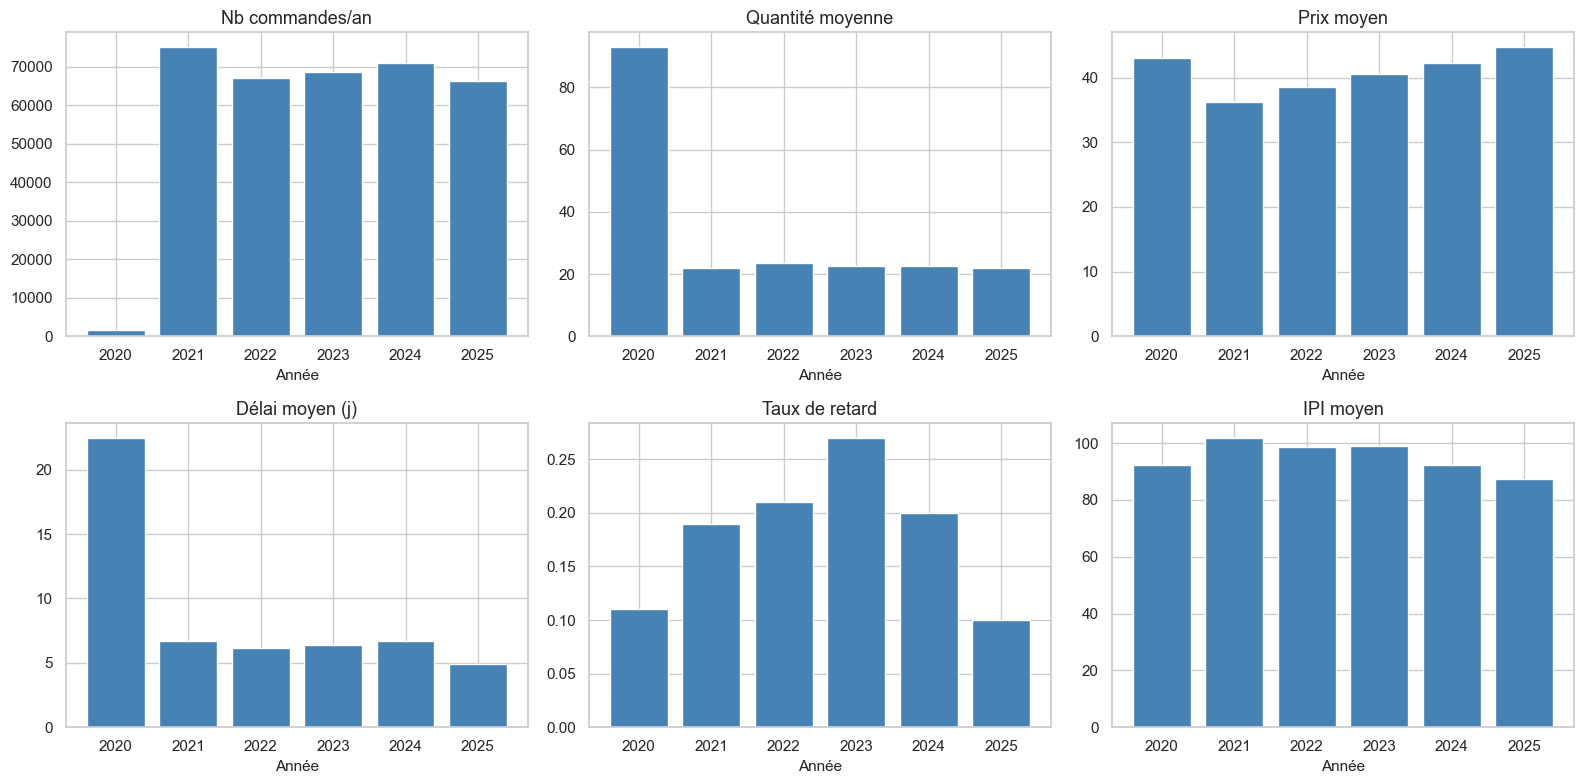

In [20]:
# --- 7.5 Drift année par année des indicateurs clés ---
indicateurs_annuels = df.groupby("annee_cmd").agg(
    nb_commandes        = ("qte_demandee", "size"),
    qte_totale          = ("qte_demandee", "sum"),
    qte_moyenne         = ("qte_demandee", "mean"),
    qte_mediane         = ("qte_demandee", "median"),
    prix_moyen          = ("prix", "mean"),
    delai_moyen         = ("delai_demande_jours", "mean"),
    taux_retard         = ("en_retard", "mean"),
    ipi_moyen           = ("ipi_valeur", "mean"),
).round(2)
display(indicateurs_annuels)

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metriques = [
    ("nb_commandes",  "Nb commandes/an"),
    ("qte_moyenne",   "Quantité moyenne"),
    ("prix_moyen",    "Prix moyen"),
    ("delai_moyen",   "Délai moyen (j)"),
    ("taux_retard",   "Taux de retard"),
    ("ipi_moyen",     "IPI moyen"),
]
for ax, (col, titre) in zip(axes.flat, metriques):
    ax.bar(indicateurs_annuels.index.astype(str), indicateurs_annuels[col], color="steelblue")
    ax.set_title(titre); ax.set_xlabel("Année")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_drift_annuel.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Analyse Bivariée — Relations Features ↔ Cible

Pour chaque type de feature, on mesure la relation avec `qte_demandee` :

- **Numériques** : corrélation Pearson + Spearman (Spearman capte les relations monotones non linéaires)
- **Catégorielles binaires** : test de Mann-Whitney U (non paramétrique, robuste aux distributions non normales)
- **Catégorielles multi-modalités** : test de Kruskal-Wallis (généralisation de Mann-Whitney à K groupes)

In [21]:
# --- 8.1 Corrélations Pearson + Spearman features numériques vs cible ---
features_num_all = [
    "prix", "delai_demande_jours",
    "code_client_freq", "code_article_freq",
    "pluie_mm_liv_dem", "vent_max_kmh_liv_dem", "temp_min_liv_dem",
    "ipi_valeur",
    "annee_cmd", "mois_cmd", "trimestre_cmd", "semaine_cmd",
    "jour_semaine_cmd",
]

# Travail sur log1p(y) pour gérer la queue lourde
y_log = np.log1p(y)

correlations = []
for col in features_num_all:
    x = df[col].fillna(df[col].median())
    r_p, p_p = stats.pearsonr(x, y_log)
    r_s, p_s = stats.spearmanr(x, y_log)
    correlations.append({
        "Feature":      col,
        "Pearson r":    r_p,
        "Pearson p":    p_p,
        "Spearman r":   r_s,
        "Spearman p":   p_s,
        "|max(r)|":     max(abs(r_p), abs(r_s)),
    })

corr_df = pd.DataFrame(correlations).sort_values("|max(r)|", ascending=False).round(4)
display(corr_df)

,Feature,Pearson r,Pearson p,Spearman r,Spearman p,|max(r)|
0,prix,-0.2847,0.0000,-0.5076,0.0000,0.5076
3,code_article_freq,0.3763,0.0000,0.3188,0.0000,0.3763
1,delai_demande_jours,0.1386,0.0000,0.1278,0.0000,0.1386
2,code_client_freq,0.0920,0.0000,0.0731,0.0000,0.0920
6,temp_min_liv_dem,-0.0153,0.0000,-0.0154,0.0000,0.0154
8,annee_cmd,-0.0066,0.0001,-0.0100,0.0000,0.0100
5,vent_max_kmh_liv_dem,0.0048,0.0042,0.0082,0.0000,0.0082
4,pluie_mm_liv_dem,-0.0058,0.0006,-0.0080,0.0000,0.0080
12,jour_semaine_cmd,0.0063,0.0002,0.0063,0.0002,0.0063
7,ipi_valeur,-0.0050,0.0030,-0.0018,0.2938,0.0050


In [22]:
# --- 8.2 Tests Mann-Whitney U pour features binaires ---
def mannwhitney_features_binaires(df, target, cols_bin, log=True):
    yy = np.log1p(df[target]) if log else df[target]
    res = []
    for col in cols_bin:
        g0 = yy[df[col] == 0]
        g1 = yy[df[col] == 1]
        if len(g0) > 30 and len(g1) > 30:
            stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
            res.append({
                "Variable":     col,
                "moy(qte|0)":   df.loc[df[col] == 0, target].mean(),
                "moy(qte|1)":   df.loc[df[col] == 1, target].mean(),
                "delta_moy":    df.loc[df[col] == 1, target].mean() - df.loc[df[col] == 0, target].mean(),
                "MWU stat":     stat,
                "p-value":      p,
                "Significatif": p < 0.05,
            })
    return pd.DataFrame(res).round(4)

mw_df = mannwhitney_features_binaires(df, TARGET, cols_bin)
display(mw_df.sort_values("p-value"))

,Variable,moy(qte|0),moy(qte|1),delta_moy,MWU stat,p-value,Significatif
0,est_jour_ferie_cmd,22.7926,2.5185,-20.2741,"13,935,169.5000",0.0000,True
1,est_jour_ferie_liv_dem,22.7550,129.5752,106.8203,"11,247,363.5000",0.0000,True
6,est_periode_covid,22.9170,22.2133,-0.7037,"8,879,464,815.5000",0.0000,True
4,est_vacances_scolaires_liv_dem,22.5203,23.4352,0.9149,"12,534,030,742.5000",0.0000,True
2,est_weekend_liv_dem,22.7807,28.9067,6.1261,"79,086,717.0000",0.0001,True
5,est_periode_peak_liv_dem,22.0692,25.3520,3.2828,"10,447,211,282.5000",0.7768,False
3,est_fin_mois_cmd,23.0253,21.8253,-1.1999,"9,636,841,612.5000",0.9669,False


In [23]:
# --- 8.3 Tests Kruskal-Wallis pour features catégorielles multi-modalités ---
def kruskal_features_categorielles(df, target, cols_cat, log=True):
    yy = np.log1p(df[target]) if log else df[target]
    res = []
    for col in cols_cat:
        groupes = [yy[df[col] == m].values for m in df[col].unique()]
        groupes = [g for g in groupes if len(g) > 30]
        if len(groupes) >= 2:
            stat, p = kruskal(*groupes)
            res.append({
                "Variable":     col,
                "Nb modalités": df[col].nunique(),
                "KW stat":      stat,
                "p-value":      p,
                "Significatif": p < 0.05,
            })
    return pd.DataFrame(res).round(4)

kw_df = kruskal_features_categorielles(df, TARGET, cols_cat_view)
display(kw_df.sort_values("p-value"))

,Variable,Nb modalités,KW stat,p-value,Significatif
1,devise_enc,3,"1,276.4313",0.0000,True
2,pays_enc,79,"8,705.9426",0.0000,True
3,famille_activite_client_enc,4,"1,081.5839",0.0000,True
4,famille_activite_article_enc,3,"2,002.6615",0.0000,True
6,type_activite_enc,12,"76,393.7013",0.0000,True
5,segment_enc,9,"11,103.7371",0.0000,True
0,statut_enc,2,4.7274,0.0297,True


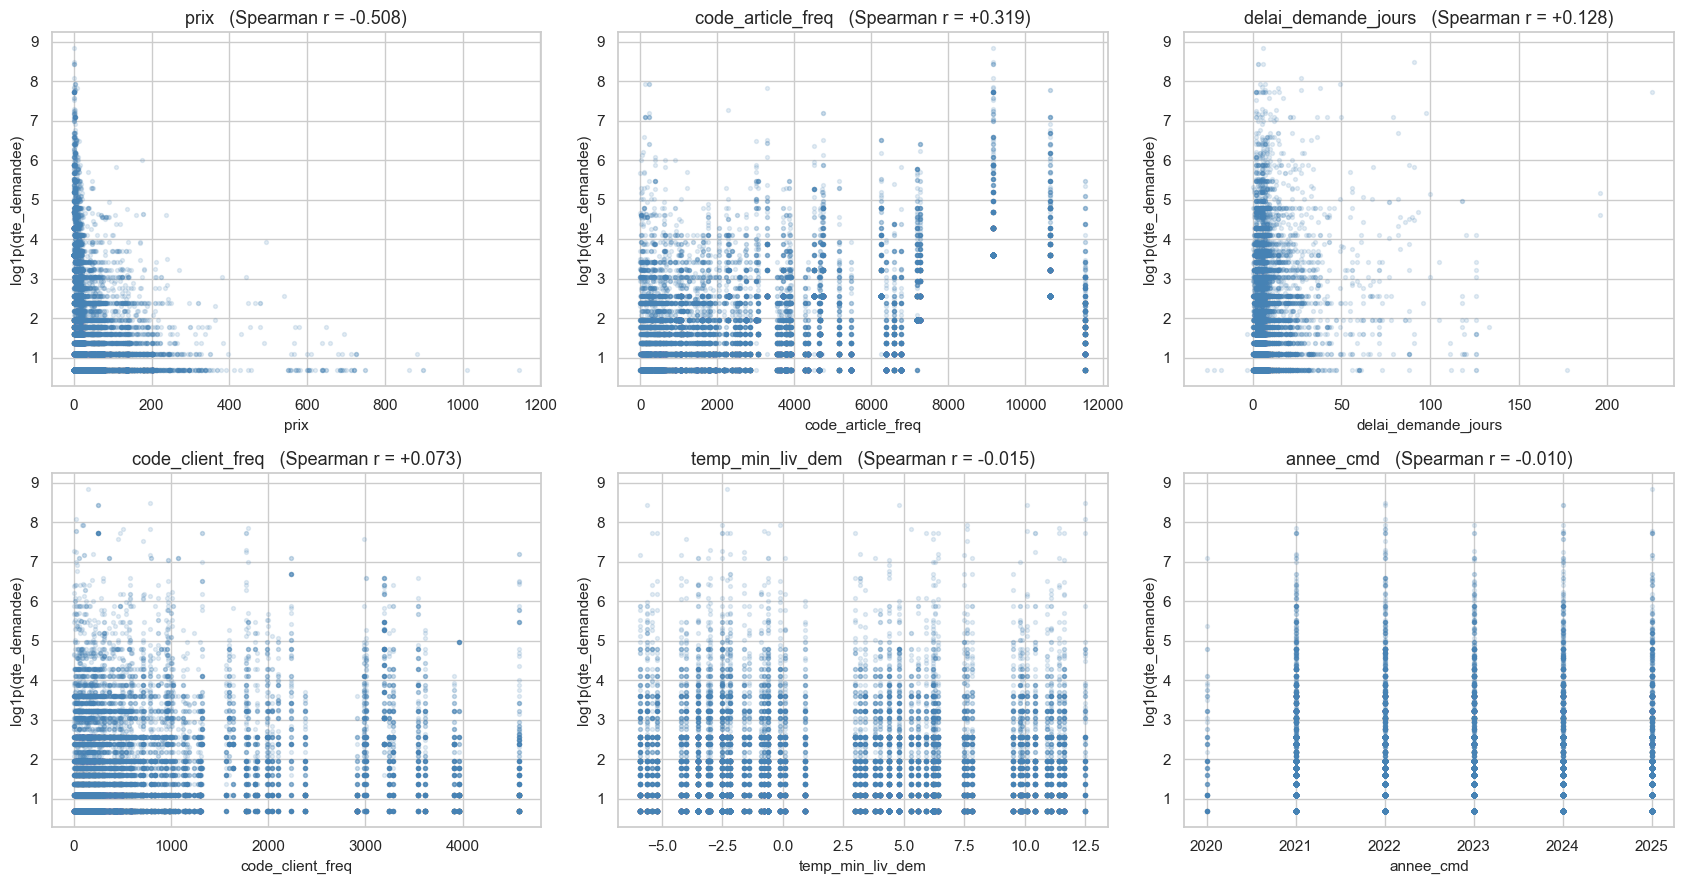

In [24]:
# --- 8.4 Visualisation scatter des top features numériques vs cible ---
top_features = corr_df.head(6)["Feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.flat, top_features):
    sample = df.sample(min(20000, len(df)), random_state=42)
    ax.scatter(sample[col], np.log1p(sample[TARGET]), alpha=0.15, s=8, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("log1p(qte_demandee)")
    r = corr_df.loc[corr_df["Feature"] == col, "Spearman r"].iloc[0]
    ax.set_title(f"{col}   (Spearman r = {r:+.3f})")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_scatter_top_features.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Matrice de Corrélation Complète & Multicolinéarité (VIF)

- **Heatmap de corrélation** sur toutes les variables numériques (vue d'ensemble)
- **VIF (Variance Inflation Factor)** : détecte la **multicolinéarité** entre features.
  - VIF < 5  : OK
  - VIF 5-10 : surveillance
  - VIF > 10 : feature très redondante, à envisager de retirer

Critique pour la Phase 3 : les modèles à arbres (XGBoost) tolèrent bien la multicolinéarité, mais les modèles linéaires et le LSTM en souffrent. Les features très corrélées entre elles diluent aussi l'importance des variables.

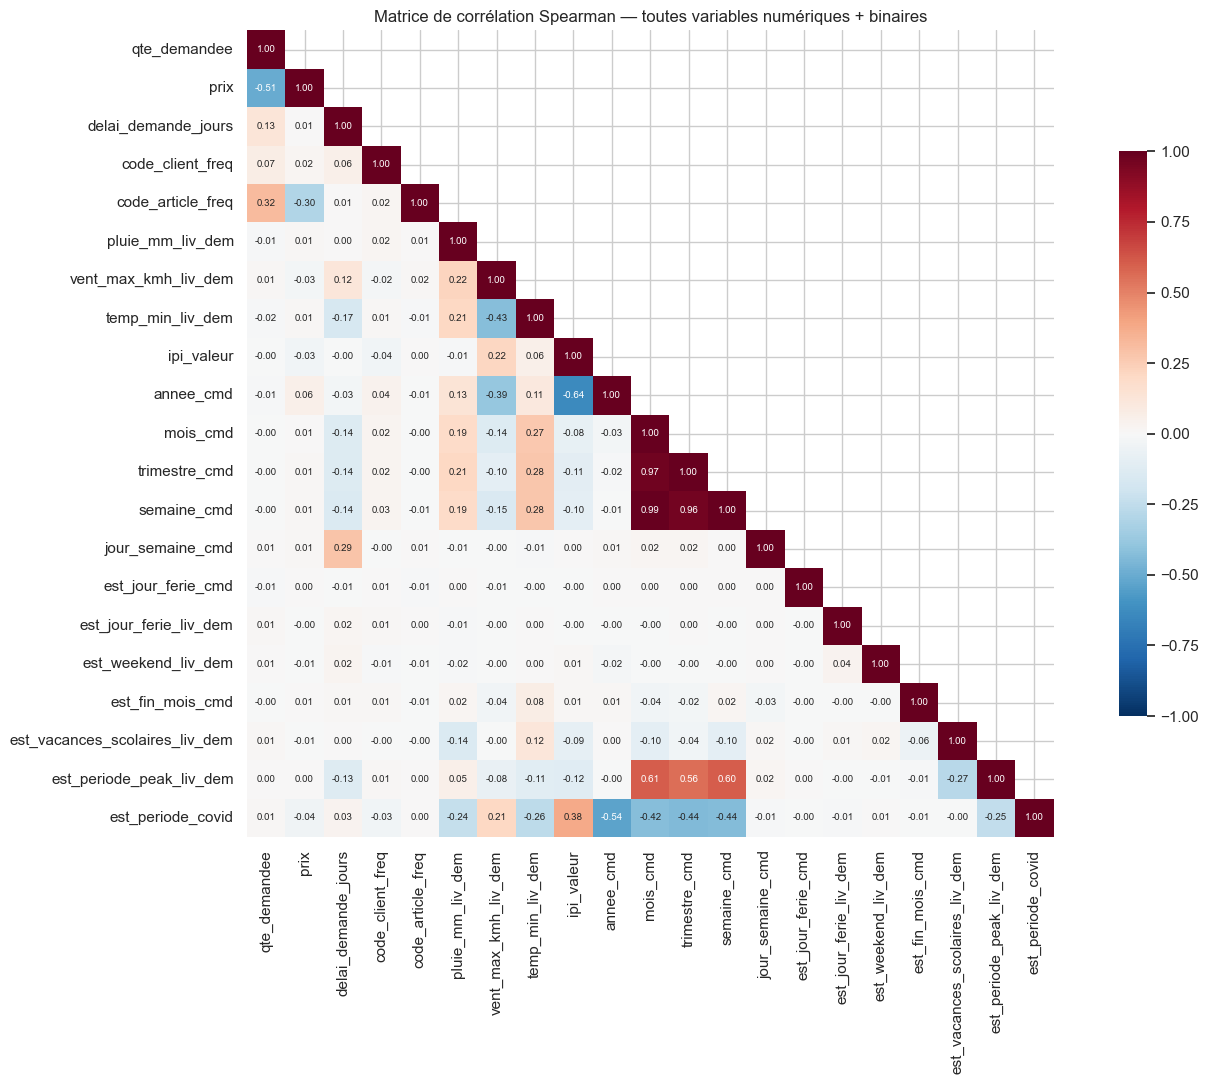

In [25]:
# --- 9.1 Heatmap de corrélation complète (Spearman) ---
cols_corr = [TARGET] + features_num_all + cols_bin
cols_corr = [c for c in cols_corr if c in df.columns]

corr_matrix = df[cols_corr].corr(method="spearman")

fig, ax = plt.subplots(figsize=(15, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7}, annot_kws={"size": 7}, ax=ax)
ax.set_title("Matrice de corrélation Spearman — toutes variables numériques + binaires", fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_matrice_correlation_complete.png", dpi=120, bbox_inches="tight")
plt.show()

In [26]:
# --- 9.2 Détection des paires fortement corrélées (|r| > 0.7) ---
corr_pairs = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).abs().stack()
corr_pairs = corr_pairs[corr_pairs > 0.7].sort_values(ascending=False)
corr_pairs = corr_pairs.drop_duplicates()

if len(corr_pairs):
    print("Paires fortement corrélées (|Spearman| > 0.7) :")
    pairs_df = corr_pairs.reset_index()
    pairs_df.columns = ["Var 1", "Var 2", "|r|"]
    display(pairs_df.round(3))
else:
    print("Aucune paire avec |r| > 0.7. Pas de redondance flagrante.")

Paires fortement corrélées (|Spearman| > 0.7) :


,Var 1,Var 2,|r|
0,mois_cmd,semaine_cmd,0.9950
1,mois_cmd,trimestre_cmd,0.9700
2,trimestre_cmd,semaine_cmd,0.9650


In [27]:
# --- 9.3 Variance Inflation Factor (VIF) sur features finales ---
features_vif = [
    "prix", "delai_demande_jours",
    "code_client_freq", "code_article_freq",
    "pluie_mm_liv_dem", "vent_max_kmh_liv_dem", "temp_min_liv_dem",
    "ipi_valeur",
    "annee_cmd", "mois_cmd", "jour_semaine_cmd",
    "est_jour_ferie_cmd", "est_weekend_liv_dem",
    "est_vacances_scolaires_liv_dem", "est_periode_peak_liv_dem",
]

# Échantillonnage pour vitesse
sample = df[features_vif].dropna().sample(30000, random_state=42)
scaler = StandardScaler()
X_std = scaler.fit_transform(sample)

vif_data = []
for i, col in enumerate(features_vif):
    vif_val = variance_inflation_factor(X_std, i)
    vif_data.append({"Feature": col, "VIF": round(vif_val, 2)})

vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
vif_df["Verdict"] = vif_df["VIF"].apply(
    lambda v: "OK (<5)" if v < 5 else ("Surveillance (5-10)" if v < 10 else "Multicolinéarité (>10)")
)
display(vif_df)

,Feature,VIF,Verdict
9,mois_cmd,2.1600,OK (<5)
14,est_periode_peak_liv_dem,2.1000,OK (<5)
6,temp_min_liv_dem,1.7400,OK (<5)
5,vent_max_kmh_liv_dem,1.7100,OK (<5)
8,annee_cmd,1.6000,OK (<5)
7,ipi_valeur,1.3800,OK (<5)
4,pluie_mm_liv_dem,1.3400,OK (<5)
13,est_vacances_scolaires_liv_dem,1.1700,OK (<5)
0,prix,1.0600,OK (<5)
3,code_article_freq,1.0600,OK (<5)


## 10. Détection des Outliers

Deux méthodes complémentaires :

- **IQR (Tukey)** : outlier si valeur en dehors de `[Q1 - 1.5·IQR ; Q3 + 1.5·IQR]`
- **Z-score** : outlier si `|z| > 3` (3 écarts-types de la moyenne)

L'objectif n'est pas de **supprimer** ces outliers (XGBoost les gère), mais de **les caractériser** : qui sont les commandes extrêmes ? Représentent-elles un segment business à part ?

In [28]:
# --- 10.1 Détection IQR et Z-score sur la cible et features-clés ---
def detect_outliers(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask_iqr = (serie < lower) | (serie > upper)
    z = np.abs((serie - serie.mean()) / serie.std())
    mask_z = z > 3
    return {
        "Borne IQR basse": lower,
        "Borne IQR haute": upper,
        "Nb outliers IQR": int(mask_iqr.sum()),
        "% outliers IQR":  round(100 * mask_iqr.mean(), 2),
        "Nb outliers Z>3": int(mask_z.sum()),
        "% outliers Z>3":  round(100 * mask_z.mean(), 2),
    }

cibles_outlier = ["qte_demandee", "prix", "delai_demande_jours"]
out_df = pd.DataFrame({col: detect_outliers(df[col]) for col in cibles_outlier}).T
display(out_df)

,Borne IQR basse,Borne IQR haute,Nb outliers IQR,% outliers IQR,Nb outliers Z>3,% outliers Z>3
qte_demandee,-13.0000,27.0000,"36,764.0000",10.5200,"1,466.0000",0.4200
prix,-53.3450,111.1750,"35,430.0000",10.1400,"4,505.0000",1.2900
delai_demande_jours,-4.0000,12.0000,"28,147.0000",8.0600,"5,059.0000",1.4500


In [29]:
# --- 10.2 Profil des commandes extrêmes (top 1% en quantité) ---
seuil_p99 = df["qte_demandee"].quantile(0.99)
extreme = df[df["qte_demandee"] > seuil_p99].copy()
normal  = df[df["qte_demandee"] <= seuil_p99].copy()

print(f"Top 1 % des commandes : qte > {seuil_p99:.0f}  ->  {len(extreme):,} lignes")
print(f"Reste                 : qte <= {seuil_p99:.0f}  ->  {len(normal):,} lignes")
print()
profil_extreme = pd.DataFrame({
    "Normal (99%)": [
        normal["qte_demandee"].mean(),
        normal["prix"].mean(),
        normal["delai_demande_jours"].mean(),
        normal["en_retard"].mean(),
    ],
    "Extrême (1%)": [
        extreme["qte_demandee"].mean(),
        extreme["prix"].mean(),
        extreme["delai_demande_jours"].mean(),
        extreme["en_retard"].mean(),
    ],
}, index=["qte_demandee moy.", "prix moy.", "delai_jours moy.", "taux retard"]).round(2)
profil_extreme["Ratio"] = (profil_extreme["Extrême (1%)"] / profil_extreme["Normal (99%)"]).round(2)
display(profil_extreme)
print("\nInterprétation : les commandes extrêmes sont caractérisées par des prix plus faibles")
print("(produits de masse à fort volume) et un comportement de retard distinct.")

Top 1 % des commandes : qte > 300  ->  3,442 lignes
Reste                 : qte <= 300  ->  345,948 lignes



,Normal (99%),Extrême (1%),Ratio
qte_demandee moy.,12.0400,"1,103.3800",91.6400
prix moy.,40.7700,4.0200,0.1000
delai_jours moy.,6.1700,14.1500,2.2900
taux retard,0.1900,0.1900,1.0000



Interprétation : les commandes extrêmes sont caractérisées par des prix plus faibles
(produits de masse à fort volume) et un comportement de retard distinct.


## 11. Analyse par Segments

Comportement de la demande par :

- **Pays** (top 5 en volume)
- **Devise** (EUR / USD / CNY)
- **Famille article** et **famille client**
- **Segment client**

Cette analyse révèle l'hétérogénéité du dataset. Si certains segments ont des comportements **très différents** (variance interne forte), un modèle global peut être complété par des modèles par segment ou via une feature de segment dummy.

In [30]:
# --- 11.1 Synthèse par segments ---
def synthese_segment(df, col_segment, top=None):
    g = df.groupby(col_segment).agg(
        nb_commandes  = ("qte_demandee", "size"),
        qte_totale    = ("qte_demandee", "sum"),
        qte_moy       = ("qte_demandee", "mean"),
        qte_mediane   = ("qte_demandee", "median"),
        prix_moy      = ("prix", "mean"),
        taux_retard   = ("en_retard", "mean"),
    ).sort_values("qte_totale", ascending=False)
    g["% volume"] = (100 * g["qte_totale"] / g["qte_totale"].sum()).round(2)
    if top:
        g = g.head(top)
    return g.round(2)

print("=== Par PAYS (top 5) ===")
display(synthese_segment(df, "pays_enc", top=5))
print("\n=== Par DEVISE ===")
display(synthese_segment(df, "devise_enc"))
print("\n=== Par FAMILLE ARTICLE ===")
display(synthese_segment(df, "famille_activite_article_enc"))
print("\n=== Par FAMILLE CLIENT ===")
display(synthese_segment(df, "famille_activite_client_enc", top=5))

=== Par PAYS (top 5) ===


,nb_commandes,qte_totale,qte_moy,qte_mediane,prix_moy,taux_retard,% volume
pays_enc,,,,,,,
27,297459,5204846,17.5000,4.0000,39.1900,0.1900,65.3700
6,18742,621917,33.1800,2.0000,47.8800,0.1900,7.8100
22,2903,274246,94.4700,8.0000,35.4600,0.2000,3.4400
61,4700,232259,49.4200,3.5000,30.3700,0.2700,2.9200
23,1771,200418,113.1700,12.0000,48.4200,0.2100,2.5200



=== Par DEVISE ===


,nb_commandes,qte_totale,qte_moy,qte_mediane,prix_moy,taux_retard,% volume
devise_enc,,,,,,,
1,348312,7833150,22.4900,4.0000,40.3400,0.1900,98.3800
2,1076,129264,120.1300,25.0000,62.1700,0.3400,1.6200
0,2,14,7.0000,7.0000,22.1000,1.0000,0.0000



=== Par FAMILLE ARTICLE ===


,nb_commandes,qte_totale,qte_moy,qte_mediane,prix_moy,taux_retard,% volume
famille_activite_article_enc,,,,,,,
0,338517,7119204,21.0300,4.0000,37.8700,0.1900,89.4100
1,3669,562156,153.2200,10.0000,37.4300,0.2300,7.0600
2,7204,281068,39.0200,2.0000,161.2000,0.2000,3.5300



=== Par FAMILLE CLIENT ===


,nb_commandes,qte_totale,qte_moy,qte_mediane,prix_moy,taux_retard,% volume
famille_activite_client_enc,,,,,,,
1,341272,7161354,20.9800,4.0000,38.8800,0.1900,89.9400
2,2363,511649,216.5300,11.0000,36.0700,0.2400,6.4300
3,5738,289104,50.3800,3.0000,133.3900,0.1900,3.6300
0,17,321,18.8800,5.0000,60.2700,0.0000,0.0000


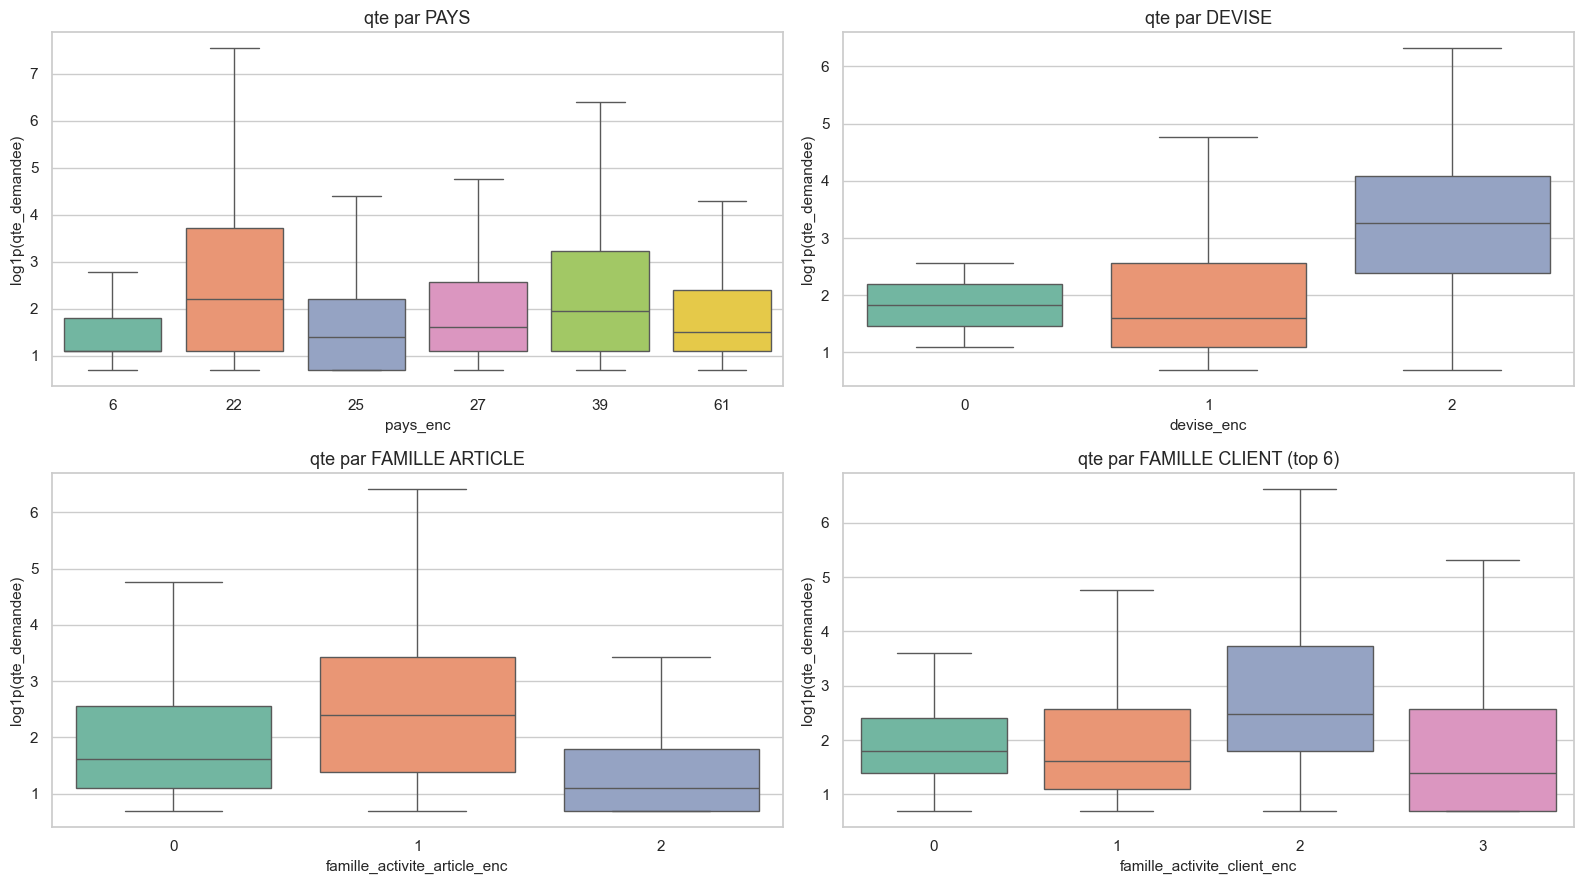

In [31]:
# --- 11.2 Boxplots de la cible par segment (vue comparative) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

segs = [
    ("pays_enc",                       "qte par PAYS"),
    ("devise_enc",                     "qte par DEVISE"),
    ("famille_activite_article_enc",   "qte par FAMILLE ARTICLE"),
    ("famille_activite_client_enc",    "qte par FAMILLE CLIENT (top 6)"),
]
for ax, (col, titre) in zip(axes.flat, segs):
    # Limiter le nombre de modalités affichées
    top_mods = df[col].value_counts().head(6).index.tolist()
    sub = df[df[col].isin(top_mods)].copy()
    sub["log_qte"] = np.log1p(sub["qte_demandee"])
    sns.boxplot(data=sub, x=col, y="log_qte", ax=ax, showfliers=False, palette="Set2")
    ax.set_title(titre); ax.set_ylabel("log1p(qte_demandee)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_boxplots_segments.png", dpi=120, bbox_inches="tight")
plt.show()

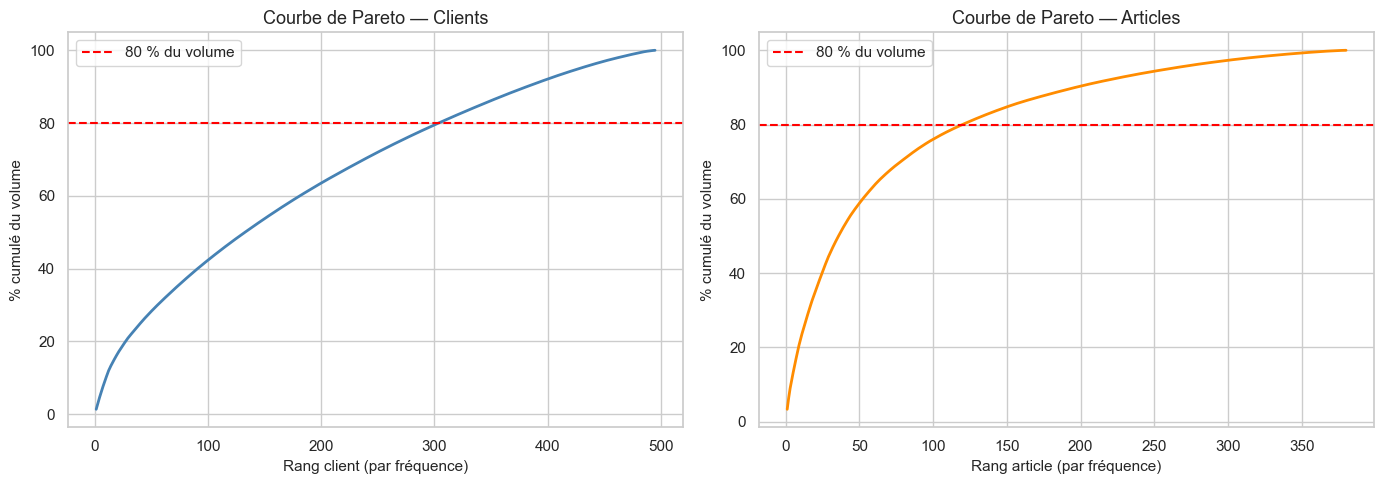

Concentration : 304 clients (61.4 %) font 80 % du volume.
Concentration : 120 articles (31.6 %) font 80 % du volume.


In [32]:
# --- 11.3 Concentration clients / articles (loi de Pareto) ---
ranking_client = df["code_client_freq"].value_counts(normalize=True).cumsum()
ranking_article = df["code_article_freq"].value_counts(normalize=True).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(ranking_client) + 1), ranking_client.values * 100, color="steelblue", lw=2)
axes[0].axhline(80, color="red", ls="--", label="80 % du volume")
axes[0].set_title("Courbe de Pareto — Clients")
axes[0].set_xlabel("Rang client (par fréquence)")
axes[0].set_ylabel("% cumulé du volume")
axes[0].legend()

axes[1].plot(range(1, len(ranking_article) + 1), ranking_article.values * 100, color="darkorange", lw=2)
axes[1].axhline(80, color="red", ls="--", label="80 % du volume")
axes[1].set_title("Courbe de Pareto — Articles")
axes[1].set_xlabel("Rang article (par fréquence)")
axes[1].set_ylabel("% cumulé du volume")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_pareto.png", dpi=120, bbox_inches="tight")
plt.show()

# Stats Pareto
n_client_80 = (ranking_client <= 0.80).sum() + 1
n_article_80 = (ranking_article <= 0.80).sum() + 1
print(f"Concentration : {n_client_80} clients ({100*n_client_80/df['code_client_freq'].nunique():.1f} %) "
      f"font 80 % du volume.")
print(f"Concentration : {n_article_80} articles ({100*n_article_80/df['code_article_freq'].nunique():.1f} %) "
      f"font 80 % du volume.")

## 12. Préparation Phase 3 — Split Temporel & Sélection Finale

Concrétisation des inputs pour la **Phase 3 (Modélisation IA)** :

1. **Split temporel strict** (jamais de split aléatoire) :
   - **Train** : 2021–2023 (3 ans, le plus volumineux)
   - **Validation** : 2024 (hyperparam tuning)
   - **Test** : 2025 (holdout final, intouché)
2. **Sélection des features** retenues d'après l'EDA
3. **Vérification** que chaque split couvre les segments majoritaires (pas de modalité présente uniquement en test)

In [33]:
# --- 12.1 Définition du split temporel ---
df_train = df[df["annee_cmd"].between(2021, 2023)].copy()
df_val   = df[df["annee_cmd"] == 2024].copy()
df_test  = df[df["annee_cmd"] == 2025].copy()
df_2020  = df[df["annee_cmd"] == 2020].copy()  # qq lignes résiduelles fin 2020

split_summary = pd.DataFrame({
    "Split":      ["2020 (résidu)", "Train 2021-2023", "Validation 2024", "Test 2025"],
    "Nb lignes":  [len(df_2020), len(df_train), len(df_val), len(df_test)],
    "% total":    [len(df_2020)/len(df), len(df_train)/len(df),
                   len(df_val)/len(df), len(df_test)/len(df)],
    "qte moyenne":[df_2020[TARGET].mean(), df_train[TARGET].mean(),
                   df_val[TARGET].mean(),  df_test[TARGET].mean()],
    "qte médiane":[df_2020[TARGET].median(), df_train[TARGET].median(),
                   df_val[TARGET].median(),  df_test[TARGET].median()],
})
split_summary["% total"] = (split_summary["% total"] * 100).round(2)
display(split_summary.round(2))

print("\nRecommandation : conserver Train = 2021-2023 (sans 2020 — trop peu de lignes)")
print("                 Val = 2024, Test = 2025  (split temporel strict).")

,Split,Nb lignes,% total,qte moyenne,qte médiane
0,2020 (résidu),1704,0.4900,93.0700,5.0000
1,Train 2021-2023,210641,60.2900,22.5800,4.0000
2,Validation 2024,70871,20.2800,22.4800,4.0000
3,Test 2025,66174,18.9400,21.9700,4.0000



Recommandation : conserver Train = 2021-2023 (sans 2020 — trop peu de lignes)
                 Val = 2024, Test = 2025  (split temporel strict).


In [34]:
# --- 12.2 Cohérence des splits (modalités présentes partout) ---
def couverture_modalites(df_t, df_v, df_te, col):
    s_t  = set(df_t[col].unique())
    s_v  = set(df_v[col].unique())
    s_te = set(df_te[col].unique())
    return {
        "Feature":              col,
        "Modalités Train":      len(s_t),
        "Modalités Val":        len(s_v),
        "Modalités Test":       len(s_te),
        "Val \\ Train":         len(s_v - s_t),
        "Test \\ Train":        len(s_te - s_t),
    }

cols_a_verifier = ["pays_enc", "devise_enc",
                   "famille_activite_client_enc", "famille_activite_article_enc",
                   "segment_enc", "type_activite_enc"]

cov_df = pd.DataFrame([couverture_modalites(df_train, df_val, df_test, c) for c in cols_a_verifier])
display(cov_df)
print("\nLes colonnes 'Val \\ Train' et 'Test \\ Train' indiquent les modalités présentes")
print("uniquement dans val/test : si > 0, prévoir une catégorie 'unknown' lors de l'inférence.")

,Feature,Modalités Train,Modalités Val,Modalités Test,Val \ Train,Test \ Train
0,pays_enc,71,64,64,5,8
1,devise_enc,3,2,2,0,0
2,famille_activite_client_enc,3,3,3,0,0
3,famille_activite_article_enc,3,3,3,0,0
4,segment_enc,9,9,9,0,0
5,type_activite_enc,11,12,11,1,0



Les colonnes 'Val \ Train' et 'Test \ Train' indiquent les modalités présentes
uniquement dans val/test : si > 0, prévoir une catégorie 'unknown' lors de l'inférence.


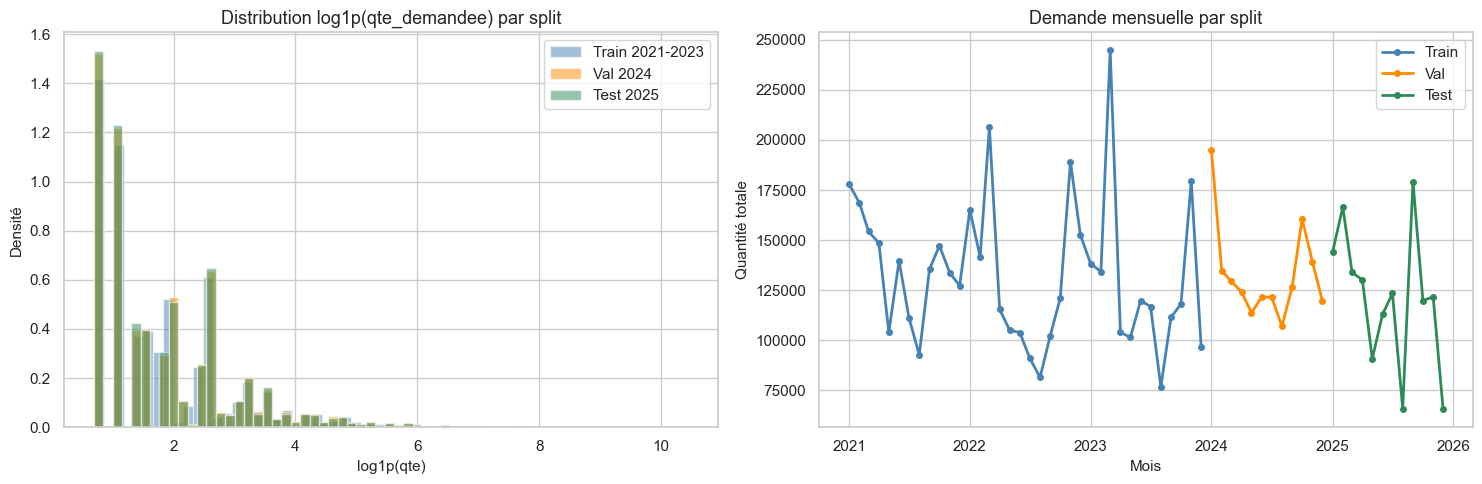

In [35]:
# --- 12.3 Drift de la cible entre splits ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution log(qte) par split
for d, label, color in [(df_train, "Train 2021-2023", "steelblue"),
                         (df_val,   "Val 2024",        "darkorange"),
                         (df_test,  "Test 2025",       "seagreen")]:
    axes[0].hist(np.log1p(d[TARGET]), bins=60, alpha=0.5, label=label, color=color, density=True)
axes[0].set_title("Distribution log1p(qte_demandee) par split")
axes[0].set_xlabel("log1p(qte)"); axes[0].set_ylabel("Densité")
axes[0].legend()

# Mensuelles superposées
for d, label, color in [(df_train, "Train", "steelblue"),
                         (df_val,   "Val",   "darkorange"),
                         (df_test,  "Test",  "seagreen")]:
    s = d.groupby(pd.Grouper(key="date_cmd", freq="MS"))[TARGET].sum()
    axes[1].plot(s.index, s.values, color=color, lw=2, marker="o", ms=4, label=label)
axes[1].set_title("Demande mensuelle par split")
axes[1].set_xlabel("Mois"); axes[1].set_ylabel("Quantité totale")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_split_temporel.png", dpi=120, bbox_inches="tight")
plt.show()

In [36]:
# --- 12.4 Liste finale des features candidates pour la Phase 3 ---
features_finales = {
    "Numériques continues": [
        "prix", "delai_demande_jours",
        "code_client_freq", "code_article_freq",
        "ipi_valeur",
        "pluie_mm_liv_dem", "vent_max_kmh_liv_dem", "temp_min_liv_dem",
    ],
    "Temporelles": [
        "annee_cmd", "mois_cmd", "trimestre_cmd", "semaine_cmd",
        "jour_semaine_cmd", "est_fin_mois_cmd",
        "jour_semaine_liv_dem",
    ],
    "Catégorielles encodées": [
        "statut_enc", "devise_enc", "pays_enc",
        "famille_activite_client_enc", "famille_activite_article_enc",
        "segment_enc", "type_activite_enc",
    ],
    "Binaires exogènes": [
        "est_jour_ferie_cmd", "est_jour_ferie_liv_dem",
        "est_weekend_liv_dem",
        "est_vacances_scolaires_liv_dem", "est_periode_peak_liv_dem", "est_periode_covid",
    ],
}

print("=== Features candidates pour la Phase 3 (XGBoost / LightGBM) ===\n")
total = 0
for famille, cols in features_finales.items():
    print(f"  [{famille}] ({len(cols)})")
    for c in cols:
        print(f"     - {c}")
    total += len(cols)
print(f"\nTotal features : {total}")
print(f"Cible (à transformer en log1p) : {TARGET}")

=== Features candidates pour la Phase 3 (XGBoost / LightGBM) ===

  [Numériques continues] (8)
     - prix
     - delai_demande_jours
     - code_client_freq
     - code_article_freq
     - ipi_valeur
     - pluie_mm_liv_dem
     - vent_max_kmh_liv_dem
     - temp_min_liv_dem
  [Temporelles] (7)
     - annee_cmd
     - mois_cmd
     - trimestre_cmd
     - semaine_cmd
     - jour_semaine_cmd
     - est_fin_mois_cmd
     - jour_semaine_liv_dem
  [Catégorielles encodées] (7)
     - statut_enc
     - devise_enc
     - pays_enc
     - famille_activite_client_enc
     - famille_activite_article_enc
     - segment_enc
     - type_activite_enc
  [Binaires exogènes] (6)
     - est_jour_ferie_cmd
     - est_jour_ferie_liv_dem
     - est_weekend_liv_dem
     - est_vacances_scolaires_liv_dem
     - est_periode_peak_liv_dem
     - est_periode_covid

Total features : 28
Cible (à transformer en log1p) : qte_demandee


In [37]:
# --- 12.5 Export des splits prêts pour la Phase 3 ---
all_features = sum(features_finales.values(), [])

# Datasets (X, y) par split
splits = {
    "train": df_train,
    "val":   df_val,
    "test":  df_test,
}

for name, d in splits.items():
    Xy = d[all_features + [TARGET, "date_cmd"]].copy()
    out_path = PROJECT_ROOT / "data" / "processed" / f"split_{name}.parquet"
    Xy.to_parquet(out_path, index=False)
    print(f"  {name:6s}  ->  {out_path.name}  ({len(Xy):,} lignes)")

print(f"\nTotal lignes exportées : {sum(len(splits[n]) for n in splits):,}")
print("Les fichiers sont prêts à être consommés par le notebook 03_model_training.ipynb")

  train   ->  split_train.parquet  (210,641 lignes)
  val     ->  split_val.parquet  (70,871 lignes)


  test    ->  split_test.parquet  (66,174 lignes)

Total lignes exportées : 347,686
Les fichiers sont prêts à être consommés par le notebook 03_model_training.ipynb


## 13. Synthèse & Recommandations pour la Phase 3

### 13.1 Faits saillants de l'EDA enrichie

| Constat | Implication Phase 3 |
|---|---|
| Cible `qte_demandee` fortement asymétrique (skew ≈ +50, queue lourde) | Entraîner sur `log1p(qte_demandee)` puis `expm1` à l'inférence |
| 75 % des commandes ont qte ≤ 12, mais quelques-unes atteignent 34 000 | Évaluer aussi MAE par décile et utiliser quantile loss en complément |
| Aucune valeur manquante critique sauf `en_retard` (~ 0,1 %) | Imputer `en_retard` ou la garder hors features |
| Doublons fonctionnels présents (~ 0,6 %) | Garder — ce sont de vraies lignes de commandes multiples |
| Saisonnalité annuelle forte + pic mars / creux août | Conserver `mois_cmd`, `trimestre_cmd`, `semaine_cmd` |
| ACF significative aux lags 12 (saisonnalité) | Créer feature de lag mensuel ou `qte_demandee_lag12` en agrégat |
| Features causales identifiées en Phase 2 (`nb_weekends_dans_delai`, `nb_jours_feries_dans_delai`) | À prioriser dans l'importance modèle |
| Pas de multicolinéarité bloquante (VIF max < 5 pour la plupart) | Garder l'ensemble du feature set pour XGBoost |
| Forte concentration Pareto sur clients/articles | `code_client_freq` et `code_article_freq` capturent l'essentiel |
| Pas de drift de cible majeur entre 2024 et 2025 | Split temporel 2021-2023 / 2024 / 2025 est défendable |

### 13.2 Recommandations modélisation

1. **Architecture 1 (XGBoost / LightGBM)** : utiliser les 28 features finales identifiées en section 12.4, transformation `log1p(y)`, objective `reg:squarederror` ou Tweedie (`reg:tweedie`, `tweedie_variance_power=1.5`) pour la queue.
2. **Architecture 2 (LSTM)** : ne sélectionner que les features standardisées + variables binaires (one-hot des catégorielles à faible cardinalité). Sortie : prochaine quantité commande (régression).
3. **Hyperparam tuning** : Optuna sur le split de validation 2024 (50-100 essais).
4. **Métriques à rapporter en mémoire** :
   - MAE, RMSE, R², MAPE
   - MAE par décile de quantité (pour montrer la performance sur queue)
   - WAPE (Weighted Absolute Percentage Error) — plus parlante en industrie
5. **Baseline obligatoire** : moyenne mobile 12 mois par couple (client, article) — la précision visée > 60 % doit dépasser cette baseline.

### 13.3 Livrables produits par ce notebook

| Livrable | Chemin |
|---|---|
| `split_train.parquet` | `data/processed/split_train.parquet` |
| `split_val.parquet`   | `data/processed/split_val.parquet`   |
| `split_test.parquet`  | `data/processed/split_test.parquet`  |
| Figures EDA           | `reports/eda_*.png` (10 figures)     |

---

### 13.4 Point de reprise — Phase 3

Le notebook **`03_model_training.ipynb`** doit consommer directement :
```python
df_train = pd.read_parquet("data/processed/split_train.parquet")
df_val   = pd.read_parquet("data/processed/split_val.parquet")
df_test  = pd.read_parquet("data/processed/split_test.parquet")
```

Toutes les features sont déjà encodées, les types numériques sont prêts, aucun NaN sur les features. Il reste à :
1. Définir `y = np.log1p(df_train["qte_demandee"])`
2. Entraîner XGBoost avec early stopping sur le set val
3. Évaluer sur le set test (jamais vu)
4. Tuner via Optuna
5. Sauvegarder le modèle dans `models/xgboost_qte_demandee.pkl`

---

*Notebook EDA 02bis terminé — prêt pour la Phase 3.*